<a href="https://colab.research.google.com/github/dr-koehler-ai/ICU-Mortality-Prediction/blob/main/Early_ICU_Mortality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Clinical Question*: Can routinely available clinical data from the first 24 hours of ICU admission predict in-hospital mortality?

In [1]:
# Early ICU Mortality Prediction
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Data modeling
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone


# =========================
# 1. Dataset Download
# =========================

from google.colab import drive
drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/AI_Healthcare/ICU_Mortality_Prediction/training_v2.csv")

data = pd.read_csv(dataset_path)

Mounted at /content/drive


**1. Dataset Overview**


*   Number of rows and attributes
*   For each of the 01713 patients a total number of 186 attributes was collected, including ids, admission information, apache-scores, clinical and laboratory results of the first hour and day.



In [2]:
print("\nShape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nPatients:", data["patient_id"].nunique())


Shape: (91713, 186)

Columns: ['encounter_id', 'patient_id', 'hospital_id', 'hospital_death', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_mi

In [3]:
audit = pd.DataFrame({
    "dtype": data.dtypes,
    "missing_n": data.isna().sum(),
    "missing_pct": data.isna().mean().mul(100),
    "n_unique": data.nunique()
})

display(audit.loc[
    ["encounter_id", "patient_id", "hospital_id", "hospital_death"]
])

print("Doppelte encounter_id:", data["encounter_id"].duplicated().sum())
print("Doppelte patient_id:", data["patient_id"].duplicated().sum())
print("Zielwerte einschließlich fehlender Werte:")
print(data["hospital_death"].value_counts(dropna=False))

display(audit.loc[audit["n_unique"] <= 1])

,dtype,missing_n,missing_pct,n_unique
encounter_id,int64,0,0.0,91713
patient_id,int64,0,0.0,91713
hospital_id,int64,0,0.0,147
hospital_death,int64,0,0.0,2


Doppelte encounter_id: 0
Doppelte patient_id: 0
Zielwerte einschließlich fehlender Werte:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


,dtype,missing_n,missing_pct,n_unique
readmission_status,int64,0,0.0,1


In [4]:
train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    stratify=data["hospital_death"],
    random_state=42
)

eda_vars = [
    "age",
    "d1_heartrate_max",
    "d1_mbp_min",
    "d1_spo2_min",
    "d1_creatinine_max",
    "d1_lactate_max"
]

missing_summary = pd.DataFrame({
    "available_n": train_data[eda_vars].notna().sum(),
    "missing_pct": train_data[eda_vars].isna().mean() * 100
})

display(
    missing_summary.sort_values("missing_pct", ascending=False).round(1)
)

missing_by_outcome = (
    train_data[eda_vars]
    .isna()
    .groupby(train_data["hospital_death"])
    .mean()
    .mul(100)
    .T
)

missing_by_outcome.columns = [
    "missing_survived_pct",
    "missing_died_pct"
]

display(missing_by_outcome.round(1))

,available_n,missing_pct
d1_lactate_max,18724,74.5
d1_creatinine_max,65255,11.1
age,69926,4.7
d1_spo2_min,73101,0.4
d1_mbp_min,73195,0.2
d1_heartrate_max,73251,0.2


,missing_survived_pct,missing_died_pct
age,4.3,8.4
d1_heartrate_max,0.2,0.2
d1_mbp_min,0.2,0.3
d1_spo2_min,0.3,0.6
d1_creatinine_max,11.1,10.6
d1_lactate_max,76.9,49.1


**2. Missing Data Analysis and Checking for Duplicates**

In [5]:
# =========================
# 2. Missing Data Analysis
# =========================

missing = train_data.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(50))

print(train_data.duplicated().sum())
print("There are no duplicates")


Top Missing Values:
 h1_bilirubin_min          0.922829
h1_bilirubin_max          0.922829
h1_lactate_min            0.919899
h1_lactate_max            0.919899
h1_albumin_max            0.913970
h1_albumin_min            0.913970
h1_pao2fio2ratio_min      0.874663
h1_pao2fio2ratio_max      0.874663
h1_arterial_ph_max        0.834197
h1_arterial_ph_min        0.834197
h1_hco3_max               0.829440
h1_hco3_min               0.829440
h1_arterial_pco2_max      0.829140
h1_arterial_pco2_min      0.829140
h1_arterial_po2_min       0.829031
h1_arterial_po2_max       0.829031
h1_wbc_max                0.828786
h1_wbc_min                0.828786
h1_calcium_max            0.827259
h1_calcium_min            0.827259
h1_platelets_min          0.825787
h1_platelets_max          0.825787
h1_bun_max                0.818591
h1_bun_min                0.818591
h1_diasbp_invasive_max    0.817882
h1_diasbp_invasive_min    0.817882
h1_sysbp_invasive_max     0.817746
h1_sysbp_invasive_min     0.81774

**3. Analysis of Target Variable**


*   With a mortality rate of 8,6%, 7915 of the 91713 patients died in-hospital. Thus, we deal with a highly imbalanced dataset.



Outcome distribution:
hospital_death
0    67038
1     6332
Name: count, dtype: int64
Mortality rate: 8.6%


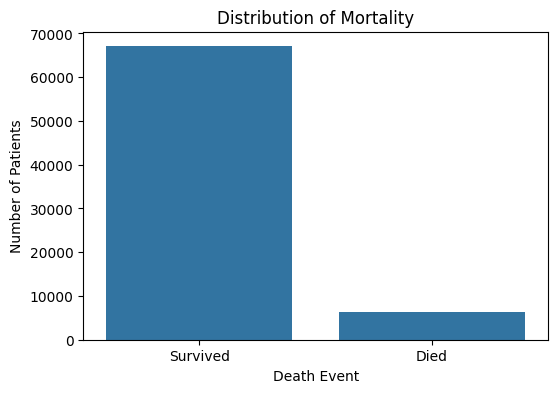

In [6]:
# =========================
# 3. Target Variable
# =========================

print("Outcome distribution:")
print(train_data["hospital_death"].value_counts())
mortality_rate = train_data["hospital_death"].mean()

print(f"Mortality rate: {mortality_rate:.1%}")
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_data,
    x="hospital_death"
)

plt.title("Distribution of Mortality")
plt.xlabel("Death Event")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Survived", "Died"])
plt.show()

**4. Univariate Analysis of Continious Variables**

*   Histogramms
*   Boxplots
*   EDA was focused on demographic and clinical variables as well as clinical and laboratory measurements within the first day, due to the many missing values in the first hour.
*   APACHE-score was discarded, due to the fact that it already incooperates many factors as a rating system for ICU-death.
*   Relevant variables of d1 were chosen based on missingness and clinical relevance.

In [7]:
data.columns.to_list()

demographic_vars = ['age',
 'bmi']

clinical_vars = ['gender',
 'ethnicity',
 'elective_surgery',
 'aids',
 'cirrhosis',
 'diabetes_mellitus',
 'hepatic_failure',
 'immunosuppression',
 'leukemia',
 'lymphoma',
 'solid_tumor_with_metastasis']

apache_vars = [
 'albumin_apache',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bilirubin_apache',
 'bun_apache',
 'creatinine_apache',
 'fio2_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'paco2_apache',
 'paco2_for_ph_apache',
 'pao2_apache',
 'ph_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'urineoutput_apache',
 'ventilated_apache',
 'wbc_apache']

d1_vars = [
 'd1_heartrate_max',
 'd1_heartrate_min',
 'd1_mbp_max',
 'd1_mbp_min',
 'd1_resprate_max',
 'd1_resprate_min',
 'd1_spo2_min',
 'd1_sysbp_max',
 'd1_sysbp_min',
 'd1_temp_max',
 'd1_temp_min',
 'd1_albumin_min',
 'd1_bilirubin_max',
 'd1_bun_max',
 'd1_calcium_max',
 'd1_calcium_min',
 'd1_creatinine_max',
 'd1_glucose_max',
 'd1_glucose_min',
 'd1_hco3_max',
 'd1_hco3_min',
 'd1_hemaglobin_max',
 'd1_hemaglobin_min',
 'd1_inr_max',
 'd1_lactate_max',
 'd1_platelets_max',
 'd1_platelets_min',
 'd1_potassium_max',
 'd1_potassium_min',
 'd1_sodium_max',
 'd1_sodium_min',
 'd1_wbc_max',
 'd1_wbc_min',
 'd1_arterial_pco2_max',
 'd1_arterial_ph_min',
 'd1_arterial_po2_min',
 'd1_pao2fio2ratio_min']

missing = train_data[d1_vars].isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(50))

variable_labels = {
    "age": "Age (Years)",
    "bmi": "BMI (kilograms/metres^2)",
    "ethnicity": "Ethnicity",
    "gender": "Gender",
    "elective_surgery": "Elective Surgery",
    "aids": "AIDS",
    "cirrhosis": "Cirrhosis",
    "diabetes_mellitus": "Diabetes Mellitus",
    "hepatic_failure": "Hepatic Failure",
    "immunosuppression": "Immunosuppression",
    "leukemia": "Leukemia",
    "lymphoma": "Lymphoma",
    "solid_tumor_with_metastasis": "Solid Tumor with Metastasis",
    "d1_heartrate_max": "Maximum Heartrate (bpm)",
    "d1_heartrate_min": "Minimum Heartrate (bpm)",
    "d1_mbp_max": "Maximum Mean Blood Pressure (mmHg)",
    "d1_mbp_min": "Minimum Mean Blood Pressure (mmHg)",
    "d1_resprate_max": "Maximum Respiratory Rate (breaths/min)",
    "d1_resprate_min": "Minimum Respiratory Rate (breaths/min)",
    "d1_spo2_min": "Minimum Blood Oxygen Saturation (%)",
    "d1_sysbp_max": "Maximum Systolic Blood Pressure (mmHg)",
    "d1_sysbp_min": "Minimum Systolic Blood Pressure (mmHg)",
    "d1_temp_max": "Maximum Temperature (°C)",
    "d1_temp_min": "Minimum Temperature (°C)",
    "d1_albumin_min": "Minimum Albumin (g/L)",
    "d1_bilirubin_max": "Maximum Bilirubin (µmol/l)",
    "d1_bun_max": "Urea Nitrogen (mmol/l)",
    "d1_calcium_max": "Maximum Calcium (mmol/l)",
    "d1_calcium_min": "Minimum Calcium (mmol/l)",
    "d1_creatinine_max": "Maximum Creatinine (µmol/l)",
    "d1_glucose_max": "Maximum Glucose (mmol/l)",
    "d1_glucose_min": "Minimum Glucose (mmol/l)",
    "d1_hco3_max": "Maximum Bicarbonat (mmol/l)",
    "d1_hco3_min": "Minimum Bicarbonat (mmol/l)",
    "d1_hemaglobin_max": "Maximum Hemoglobin (g/dl)",
    "d1_hemaglobin_min": "Minimum Hemoglobin (g/dl)",
    "d1_inr_max": "Maximum INR",
    "d1_lactate_max": "Maximum Lactate (mmol/l)",
    "d1_platelets_max": "Maximum Platelets (×10^9/L)",
    "d1_platelets_min": "Minimum Platelets (×10^9/L)",
    "d1_potassium_max": "Maximum Potassium (mmol/l)",
    "d1_potassium_min": "Minimum Potassium (mmol/l)",
    "d1_sodium_max": "Maximum Sodium (mmol/l)",
    "d1_sodium_min": "Minimum Sodium (mmol/l)",
    "d1_wbc_max": "Maximum White Blood Cell Count (×10^9/L)",
    "d1_wbc_min": "Minimum White Blood Cell Count (×10^9/L)",
    "d1_arterial_pco2_max": "Maximum Arterial PCO2 (mmHg)",
    "d1_arterial_ph_min": "Minimum Arterial pH",
    "d1_arterial_po2_min": "Minimum Arterial PO2 (mmHg)",
    "d1_pao2fio2ratio_min": "Minimum PaO2/FiO2 Ratio"
}


Top Missing Values:
 d1_lactate_max          0.744800
d1_pao2fio2ratio_min    0.719286
d1_arterial_ph_min      0.655431
d1_arterial_pco2_max    0.646218
d1_arterial_po2_min     0.646150
d1_inr_max              0.631307
d1_bilirubin_max        0.584708
d1_albumin_min          0.534551
d1_hco3_min             0.164113
d1_hco3_max             0.164113
d1_platelets_max        0.147254
d1_platelets_min        0.147254
d1_wbc_min              0.144378
d1_wbc_max              0.144378
d1_calcium_min          0.142333
d1_calcium_max          0.142333
d1_hemaglobin_min       0.132902
d1_hemaglobin_max       0.132902
d1_bun_max              0.114461
d1_sodium_min           0.110945
d1_sodium_max           0.110945
d1_creatinine_max       0.110604
d1_potassium_min        0.104389
d1_potassium_max        0.104389
d1_glucose_max          0.063023
d1_glucose_min          0.063023
d1_temp_max             0.025201
d1_temp_min             0.025201
d1_resprate_max         0.004361
d1_resprate_min      

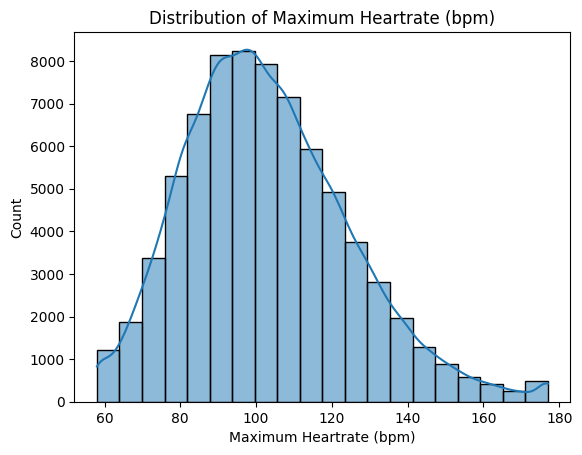

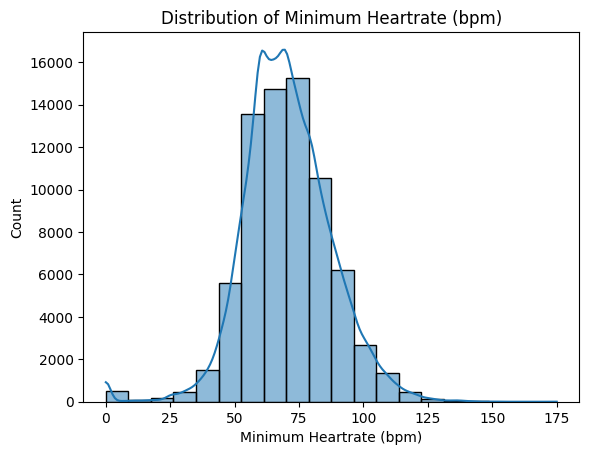

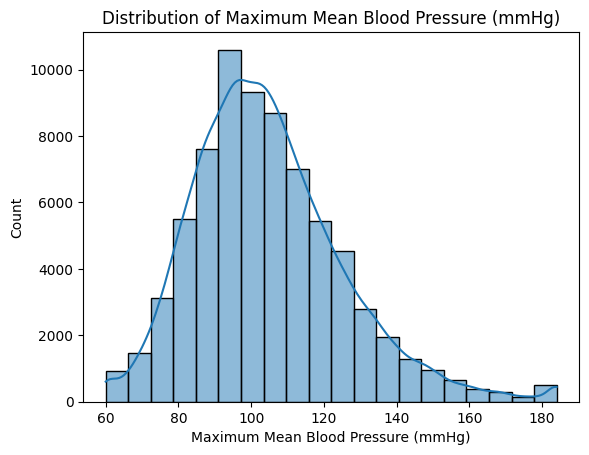

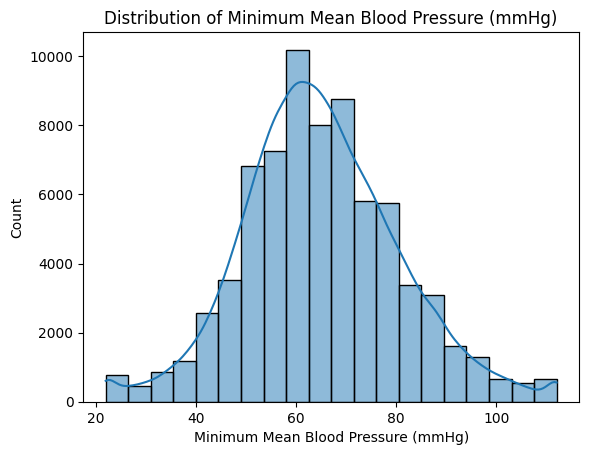

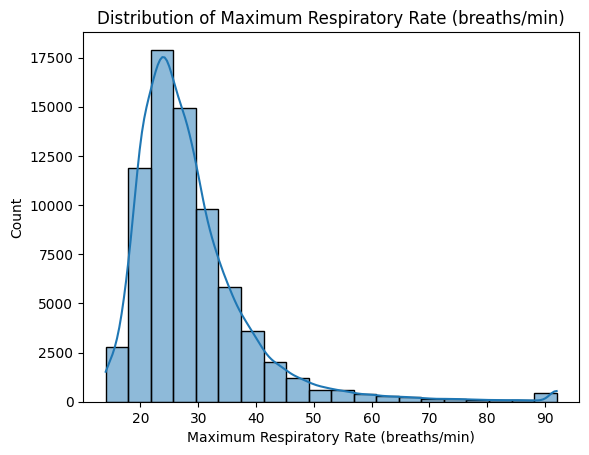

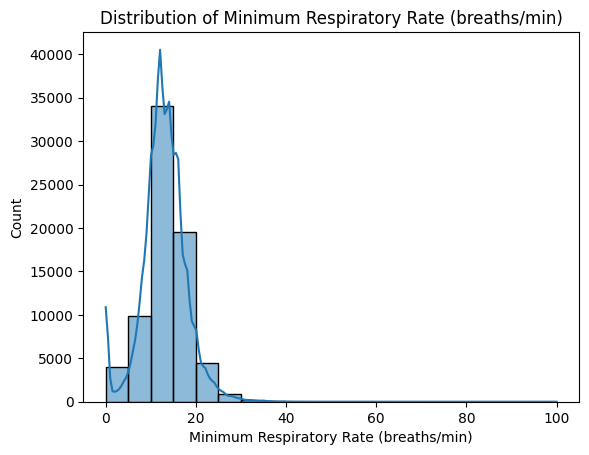

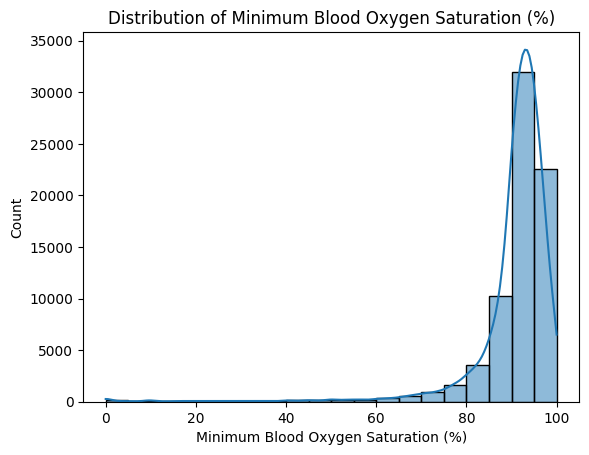

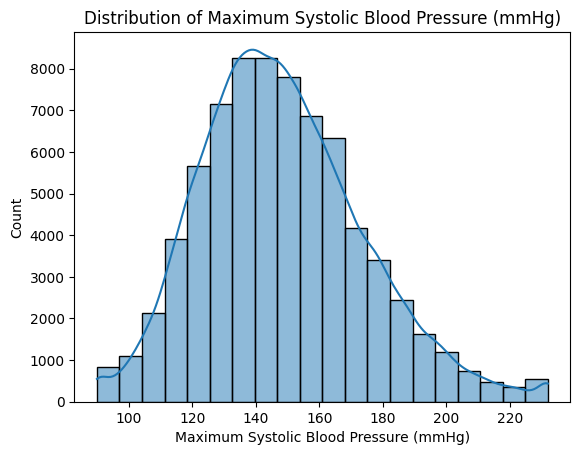

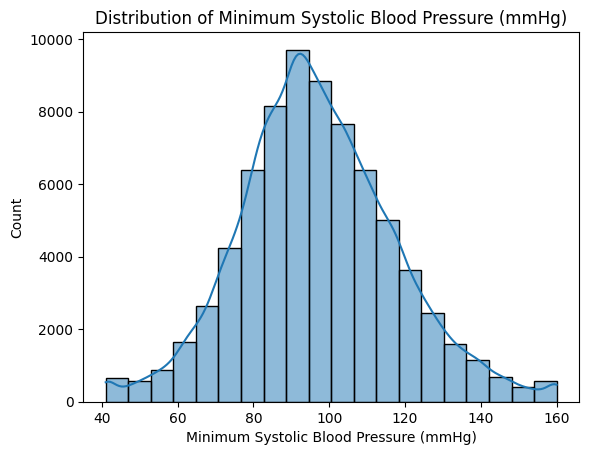

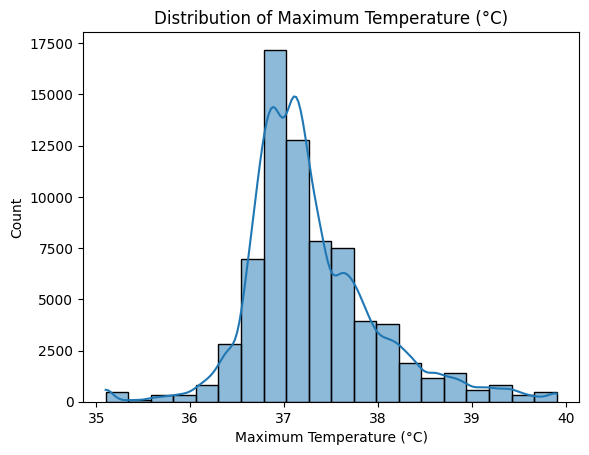

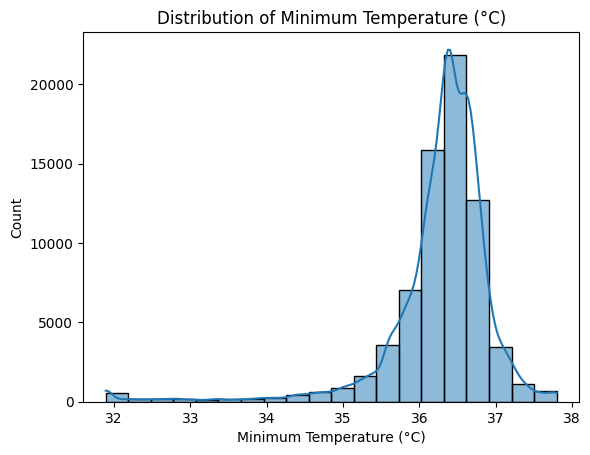

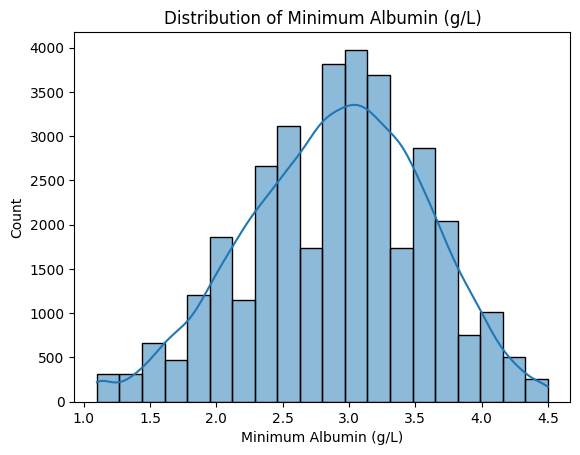

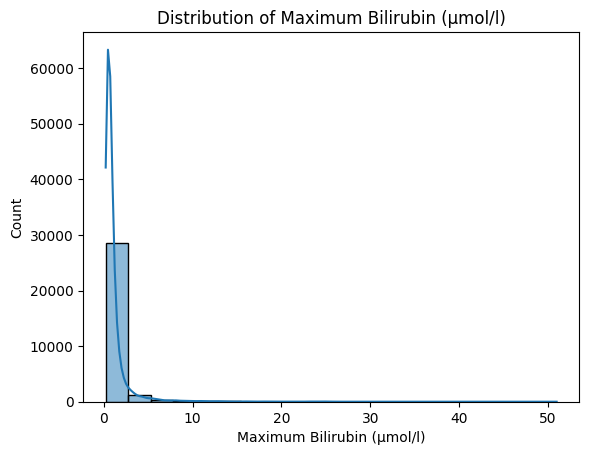

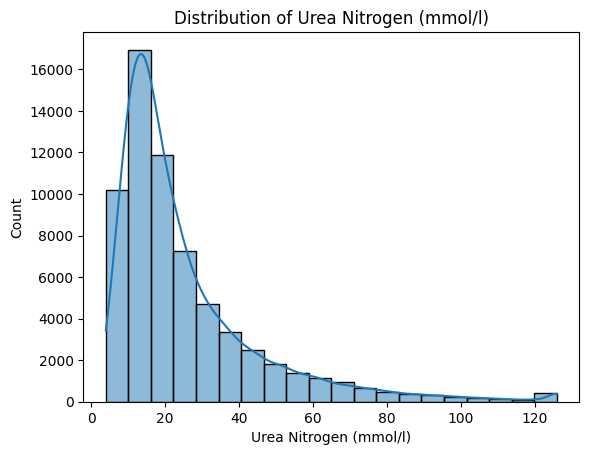

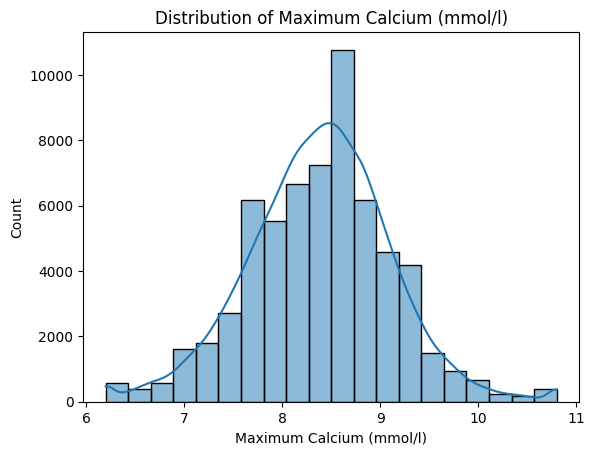

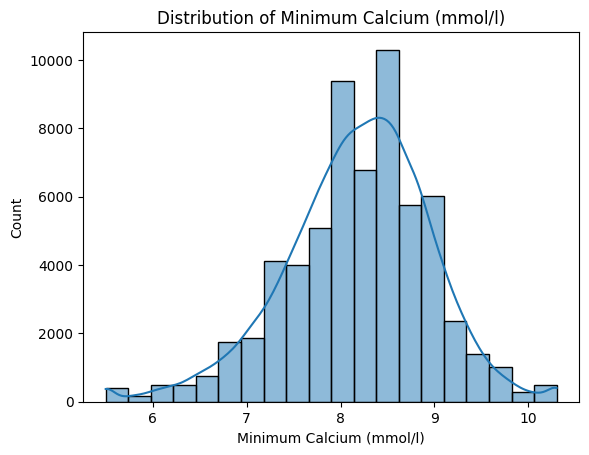

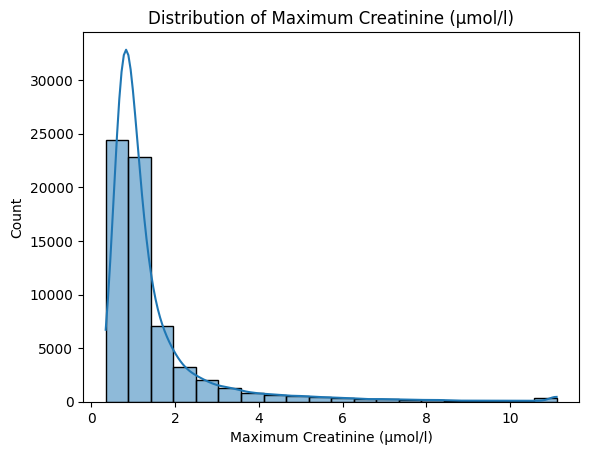

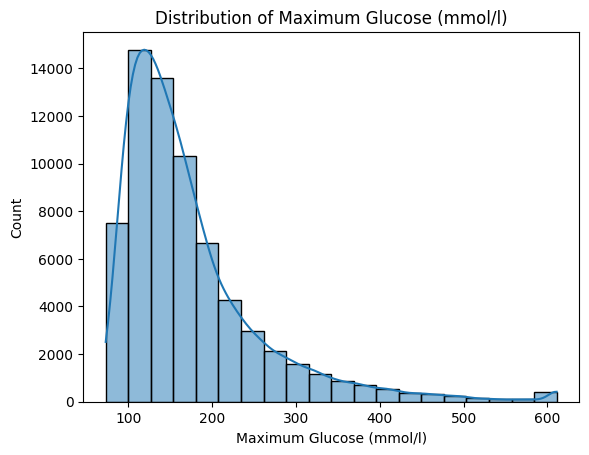

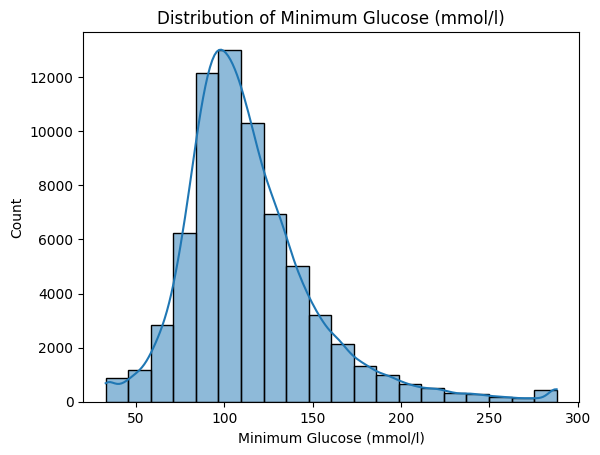

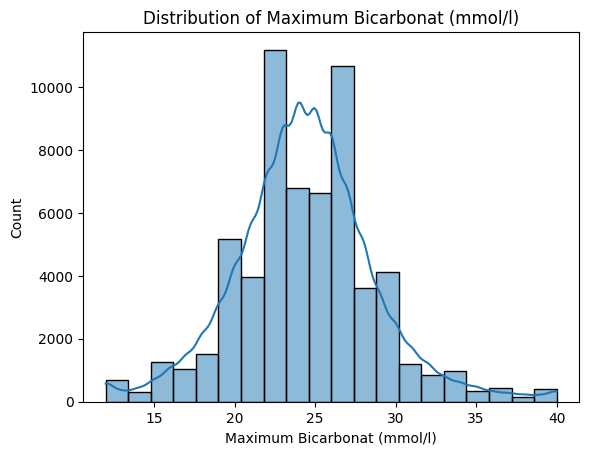

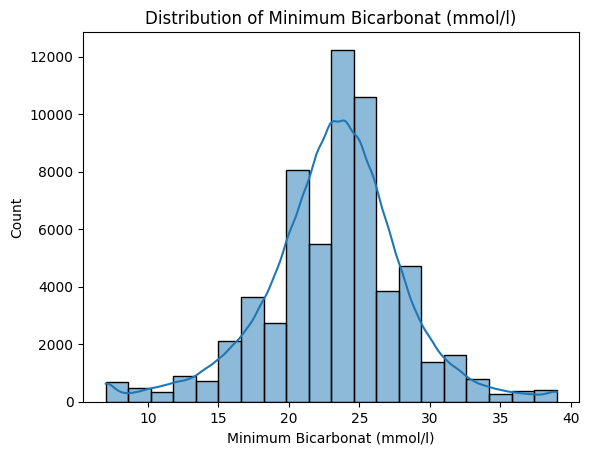

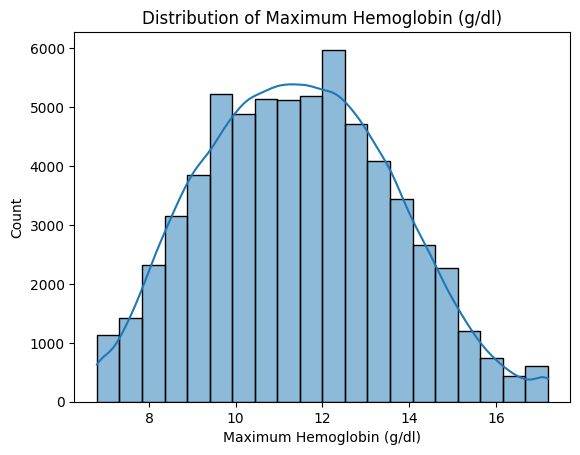

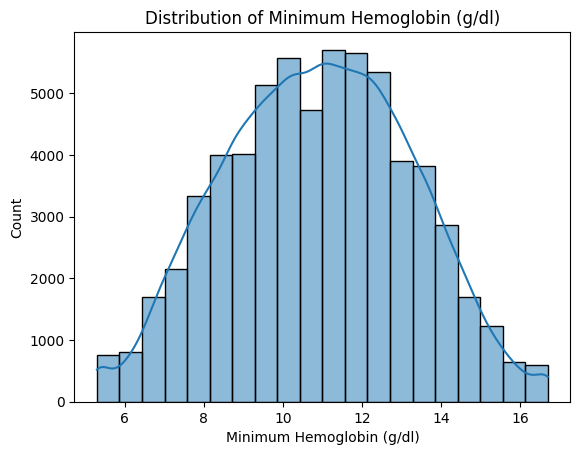

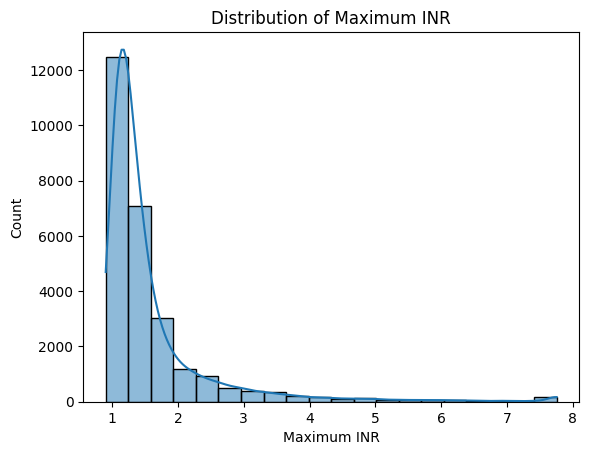

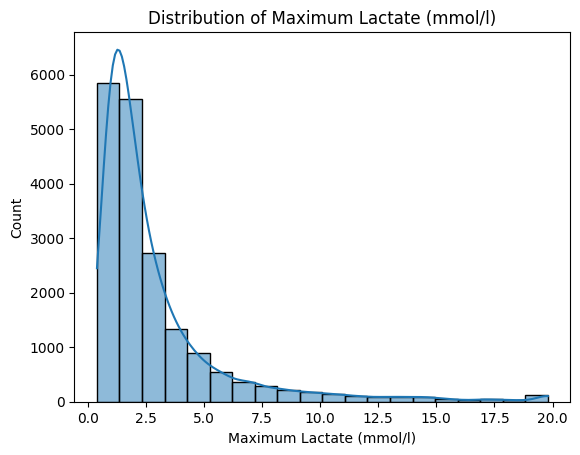

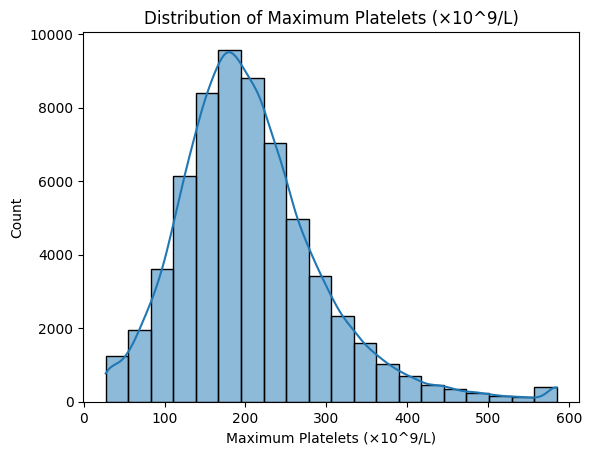

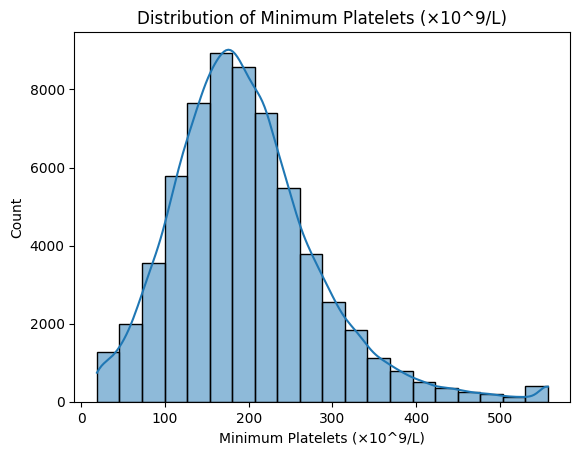

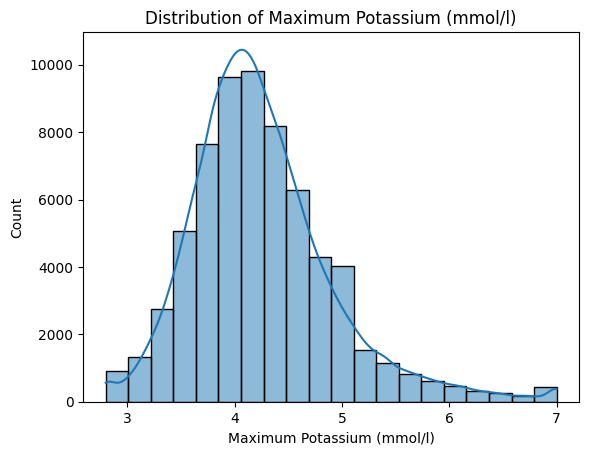

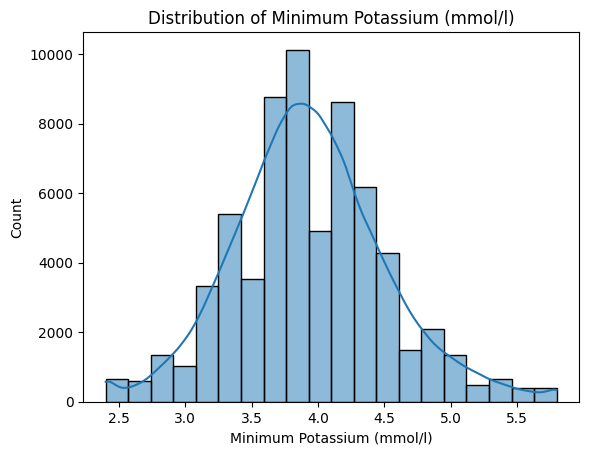

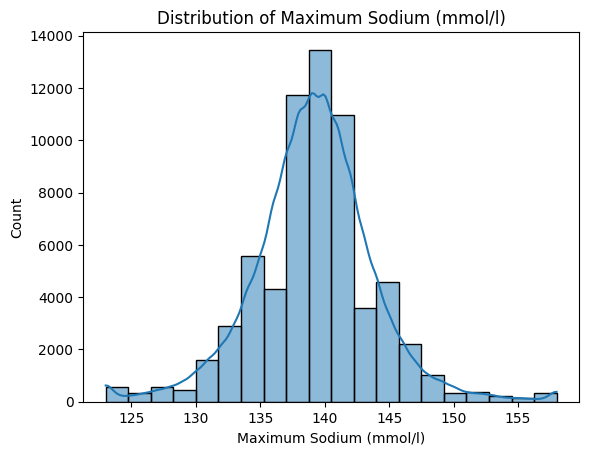

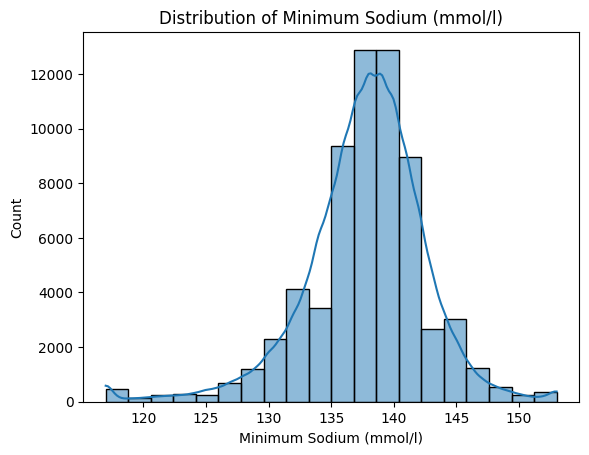

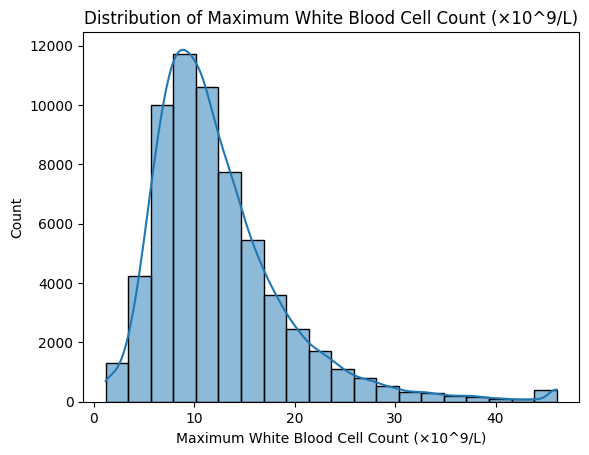

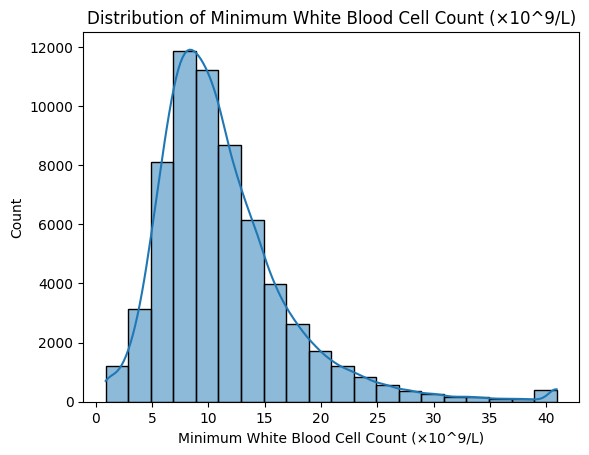

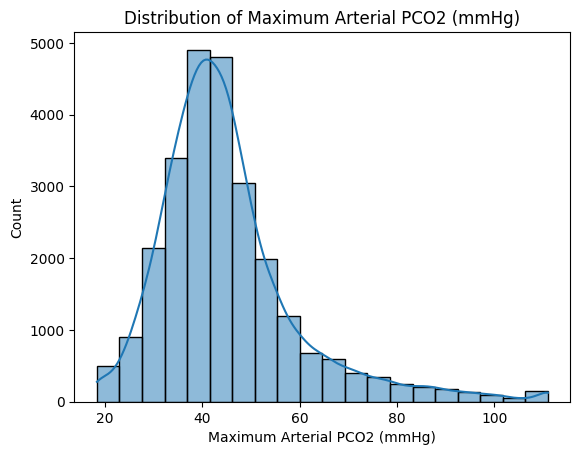

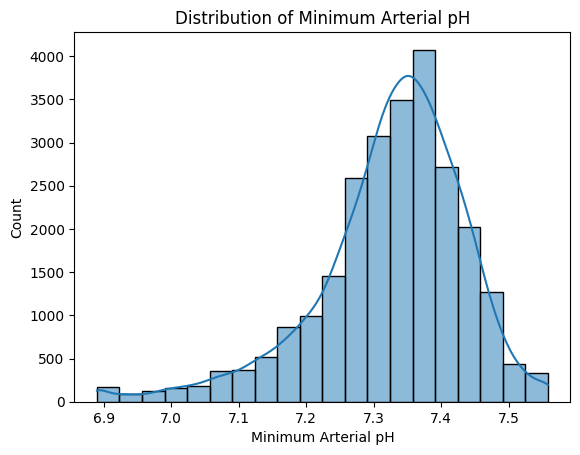

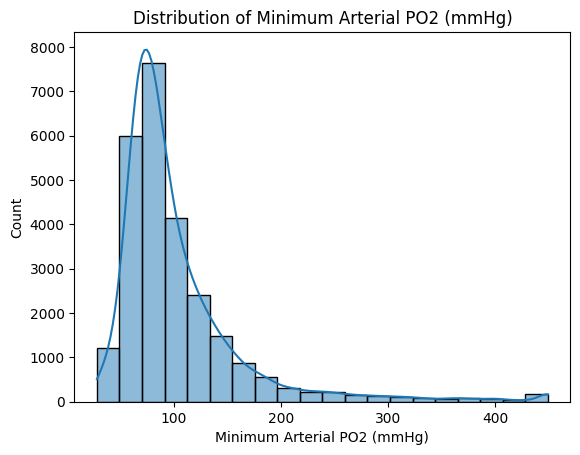

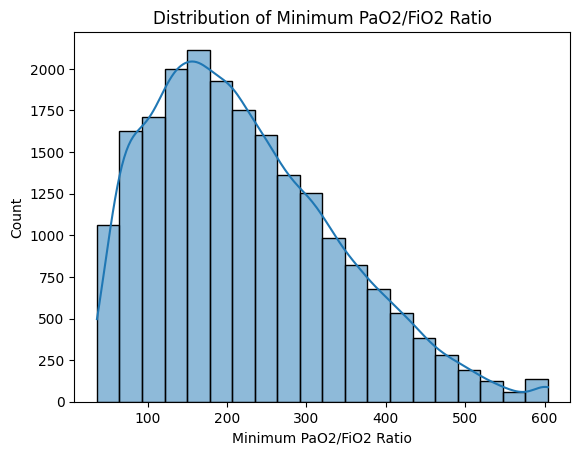

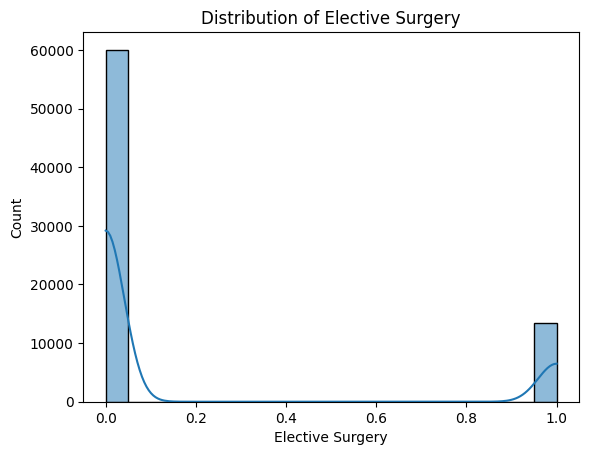

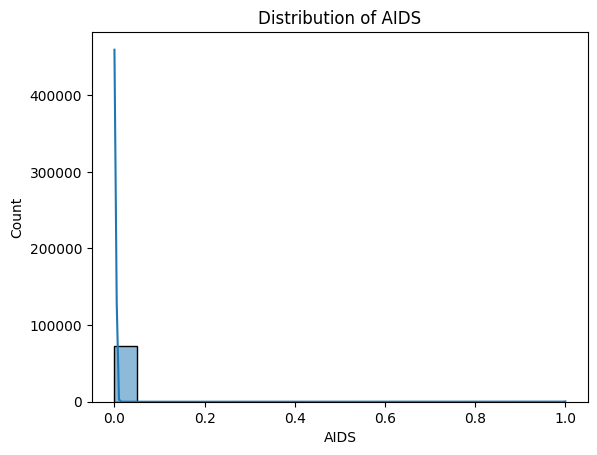

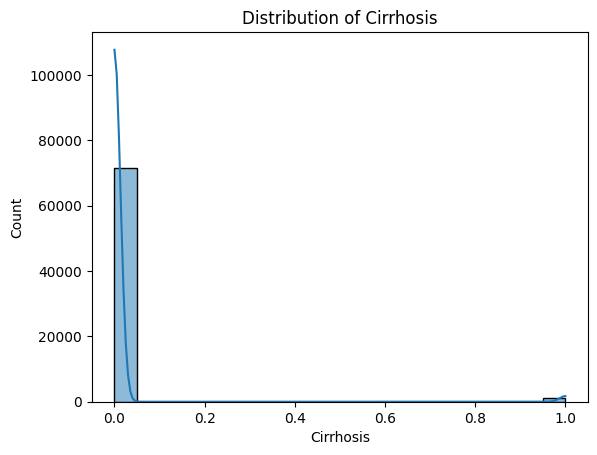

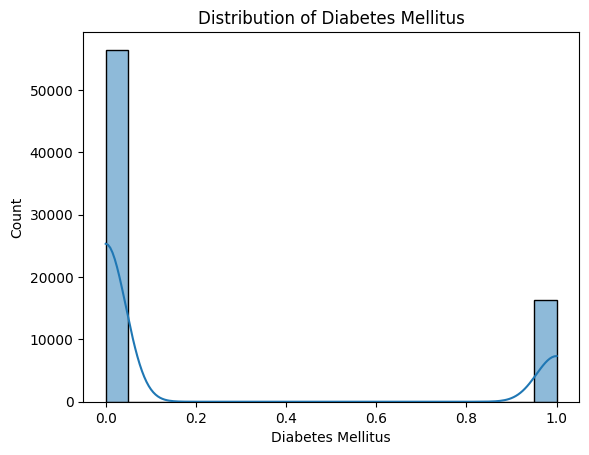

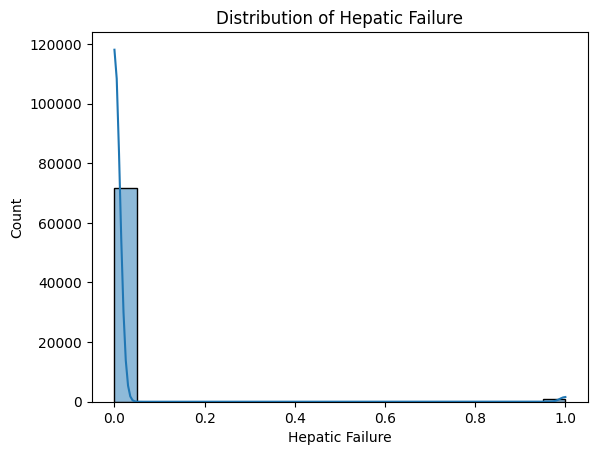

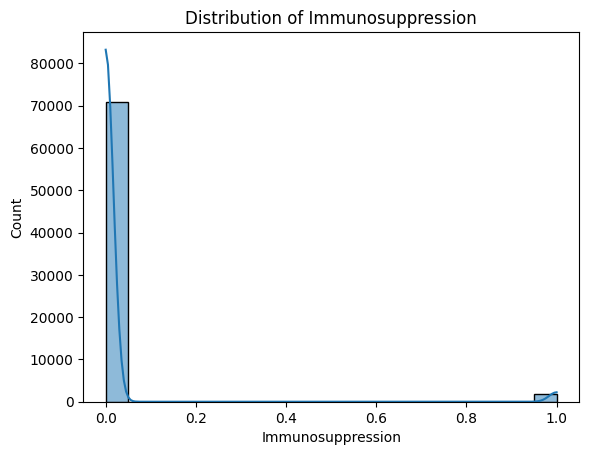

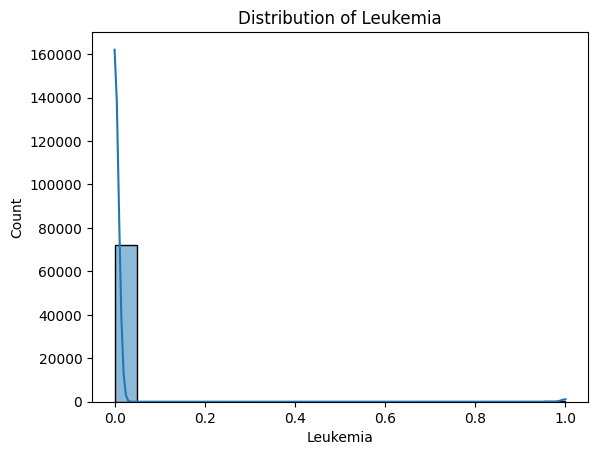

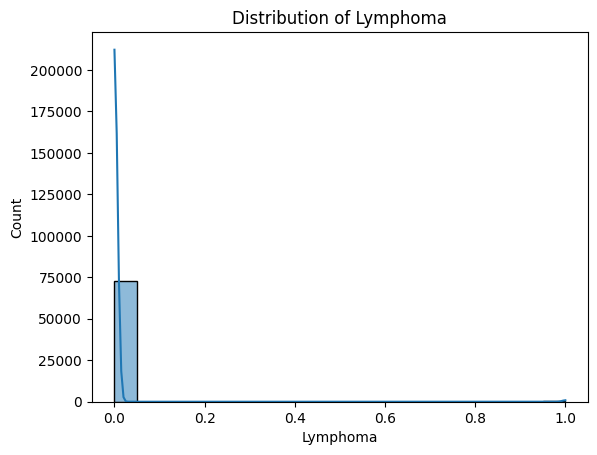

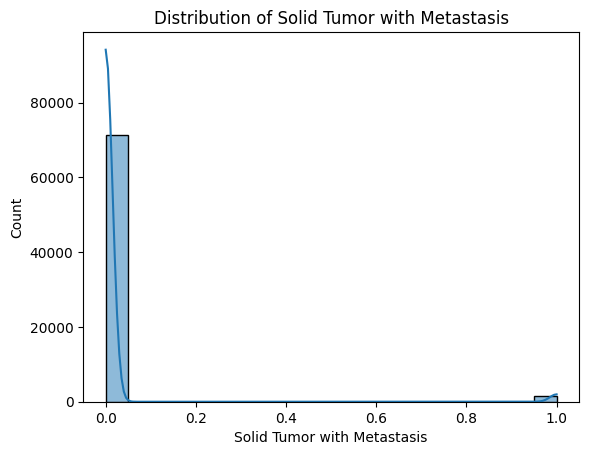

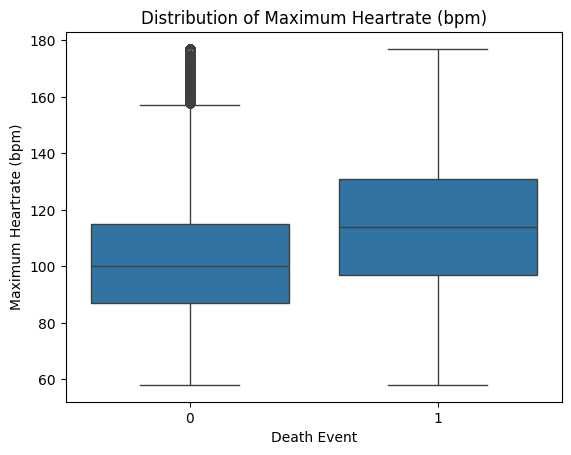

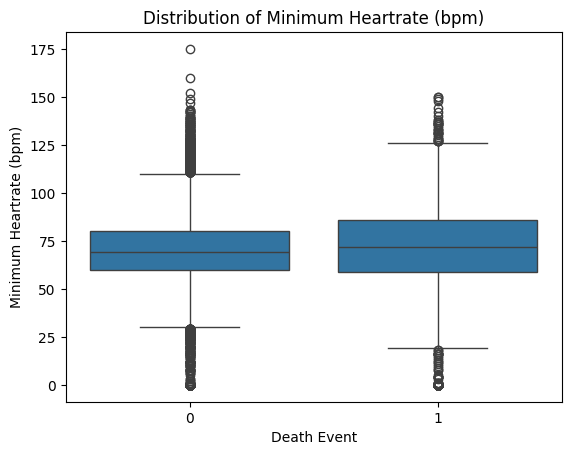

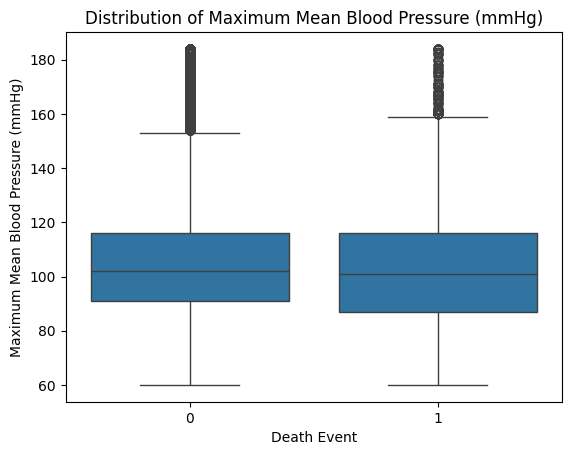

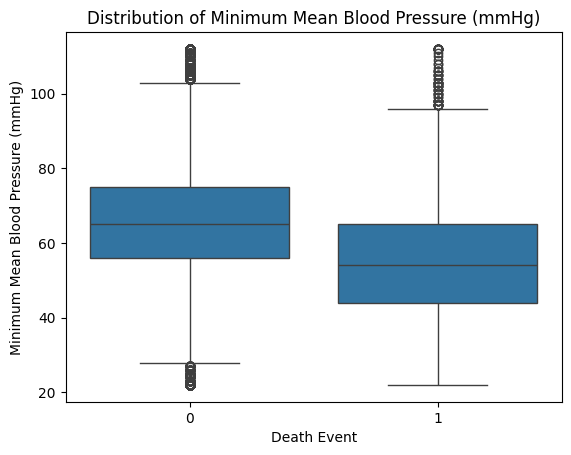

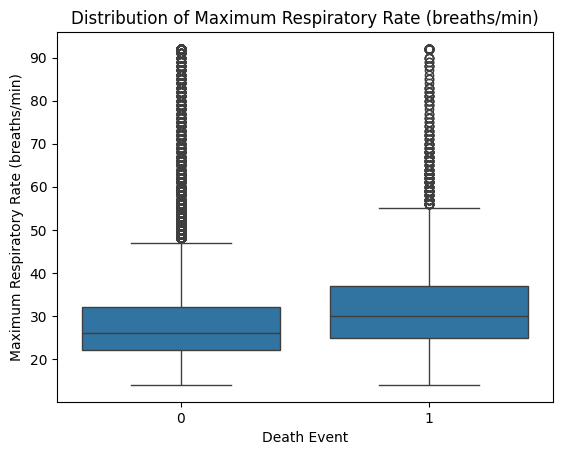

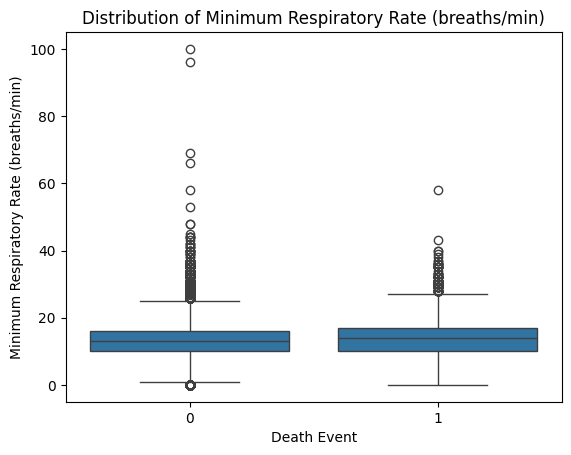

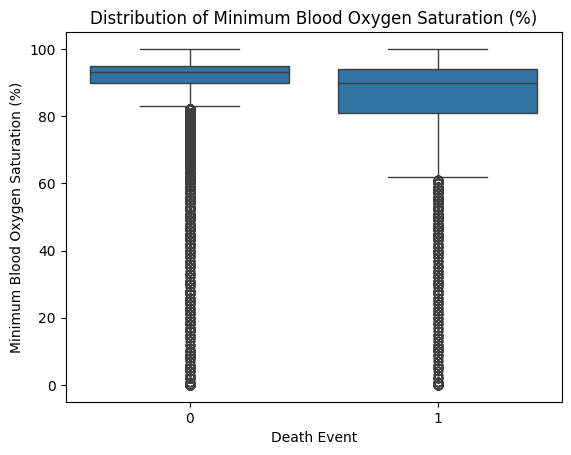

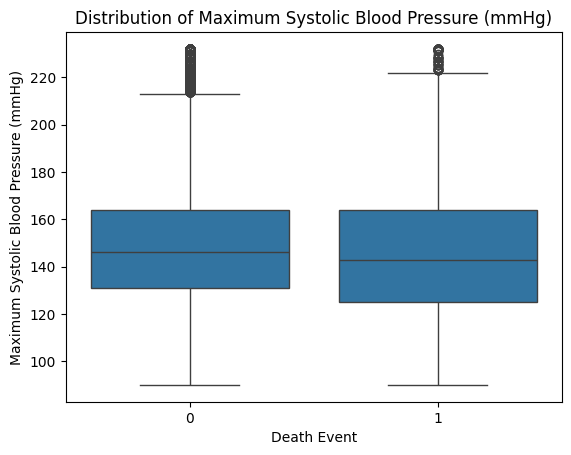

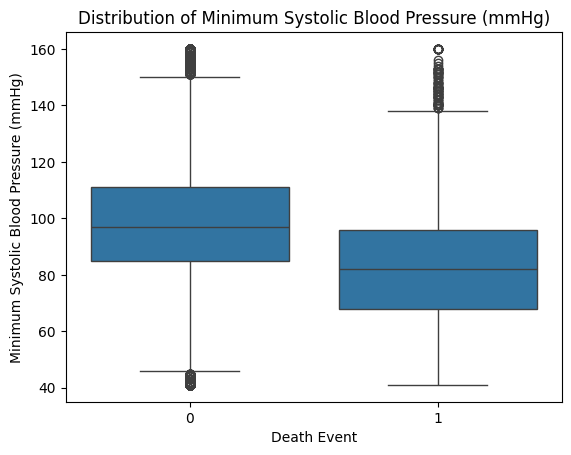

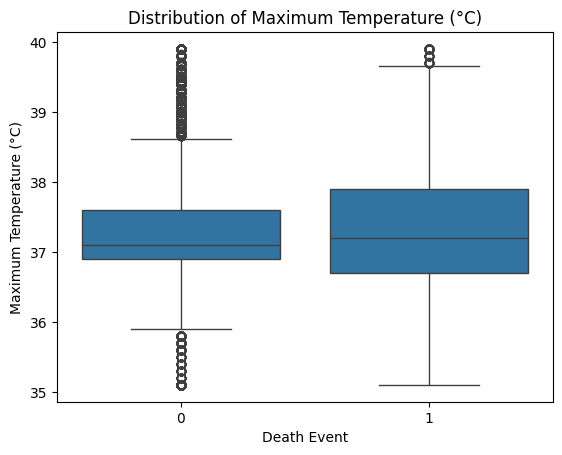

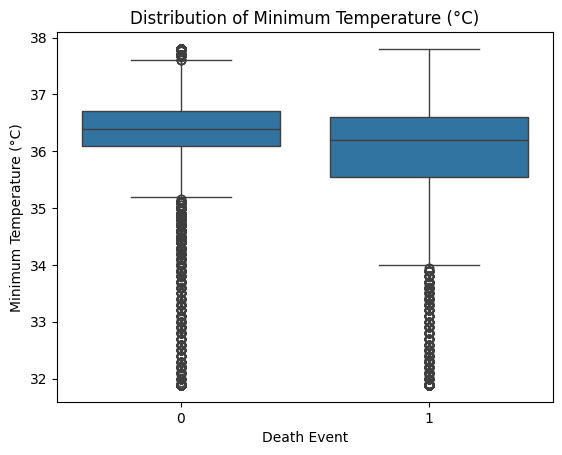

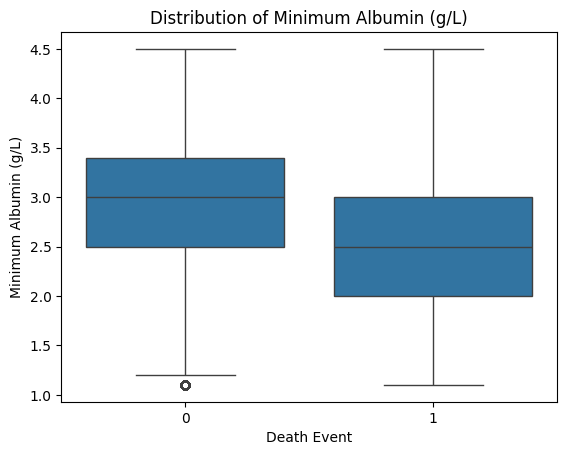

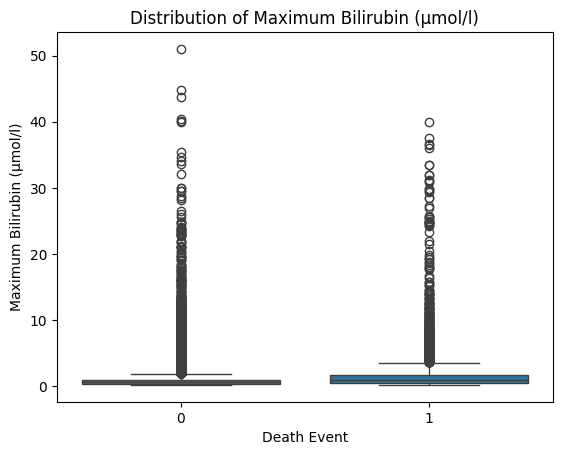

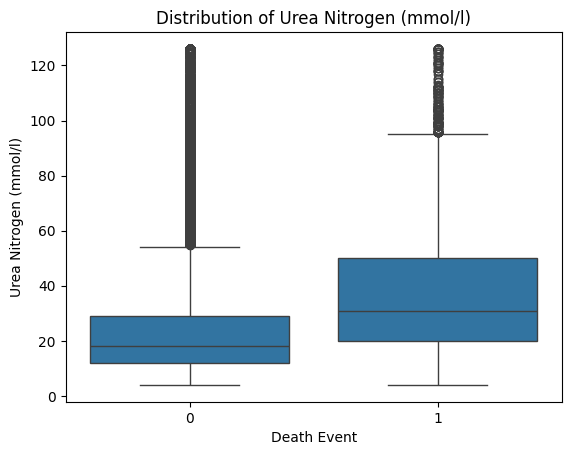

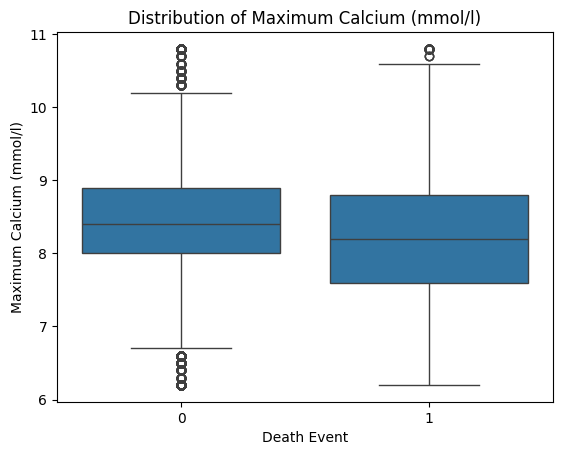

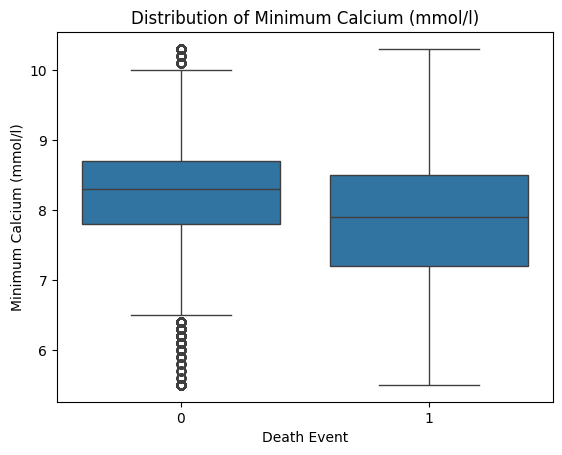

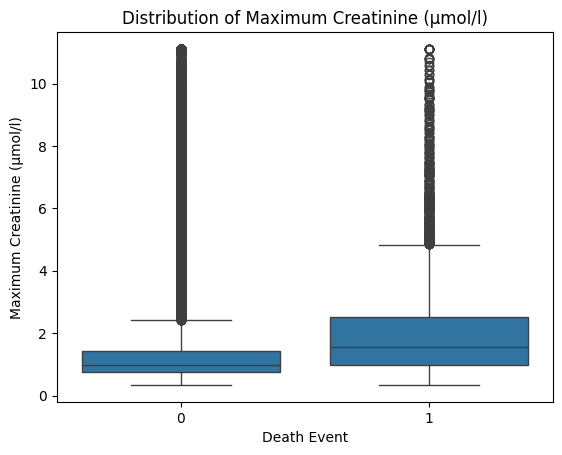

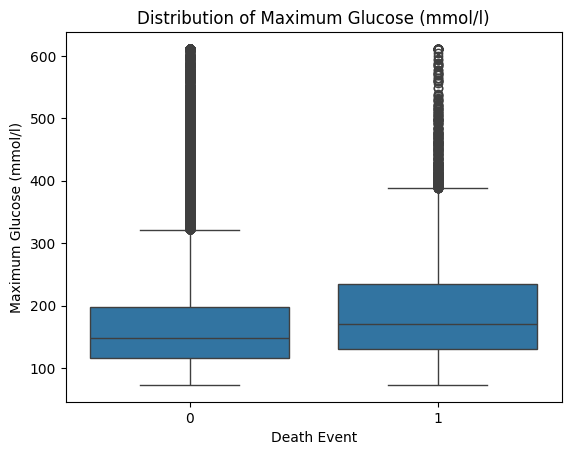

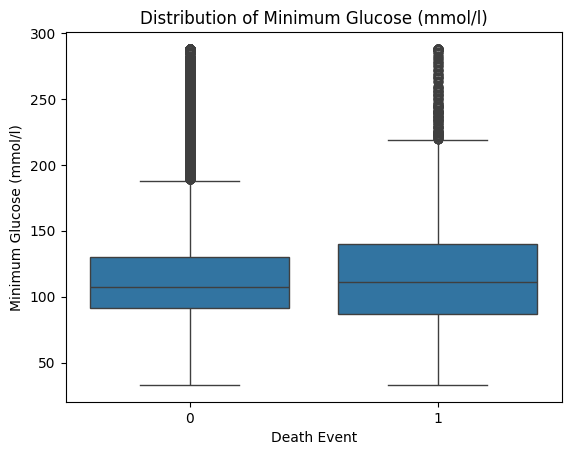

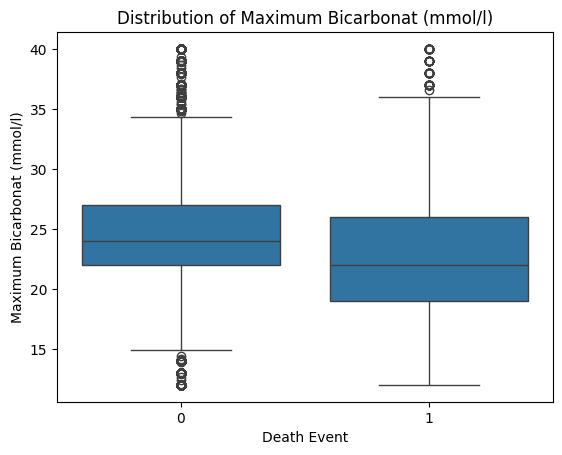

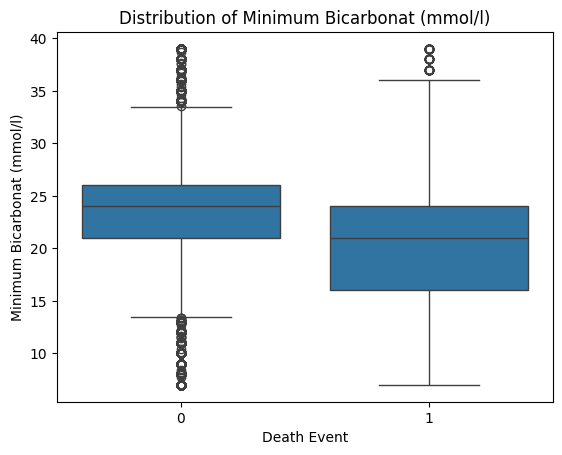

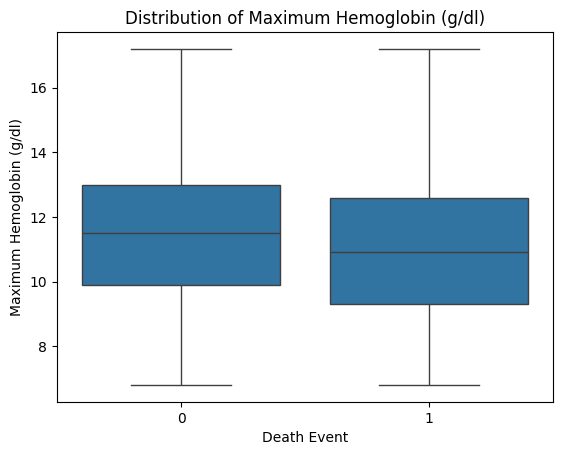

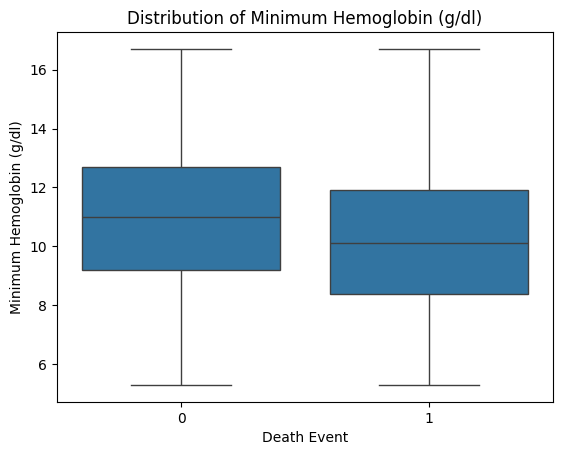

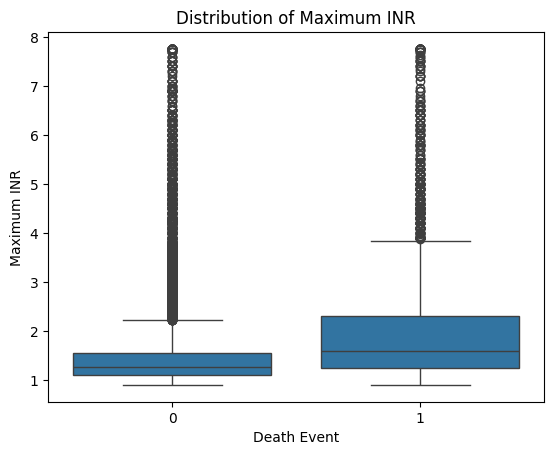

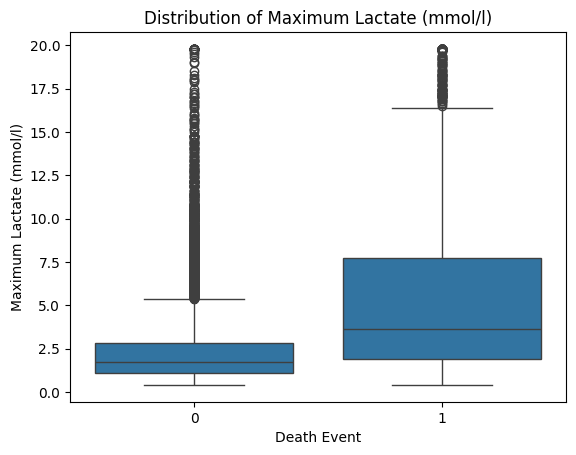

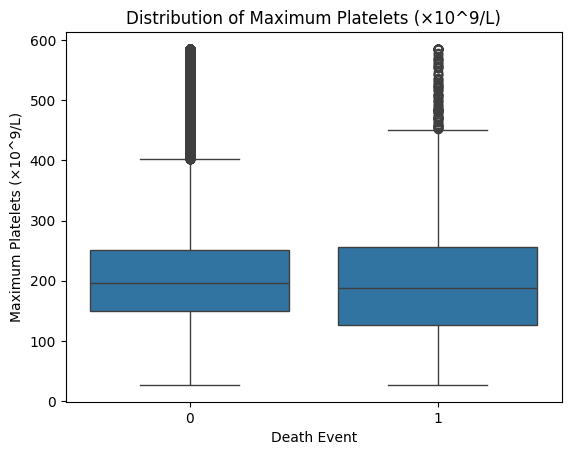

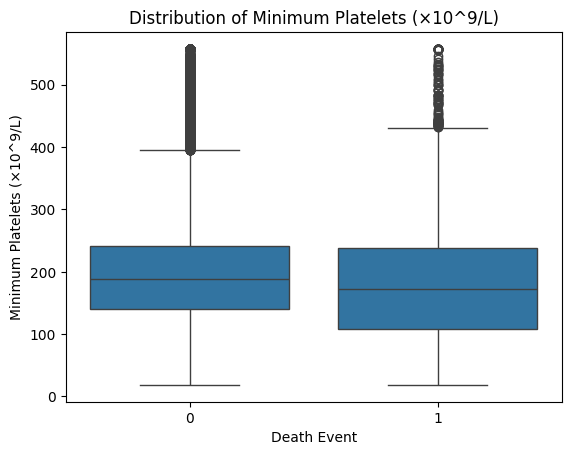

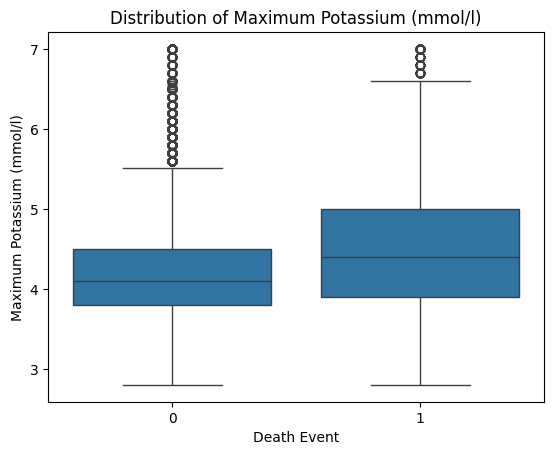

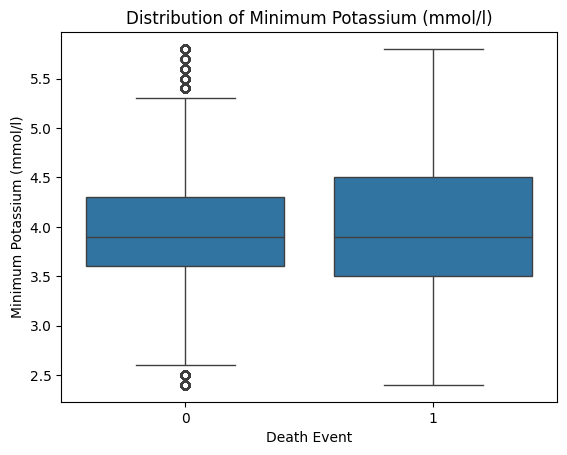

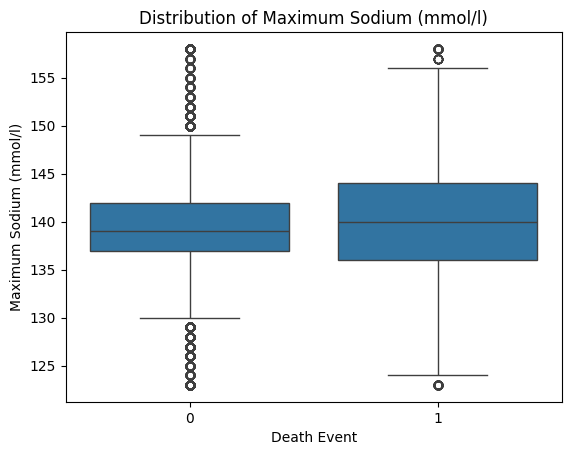

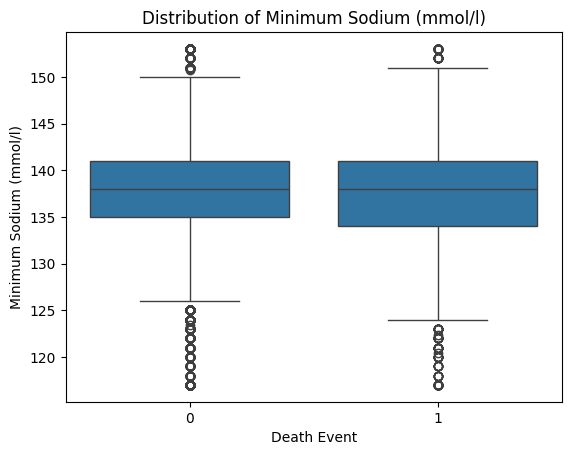

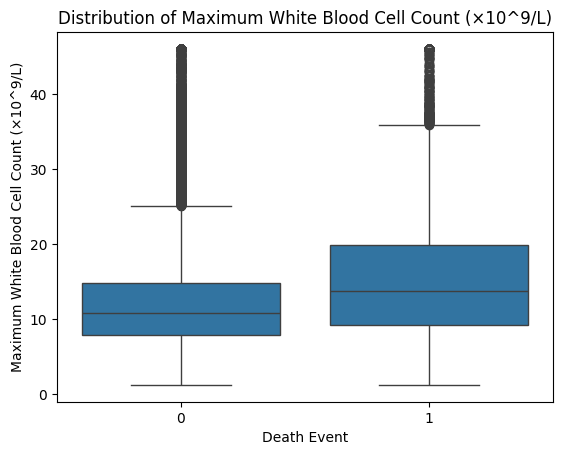

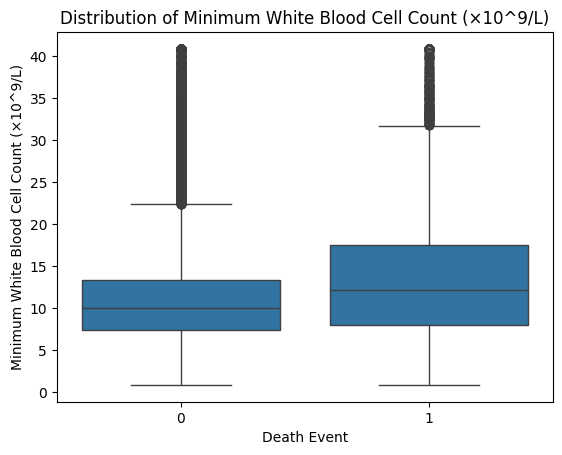

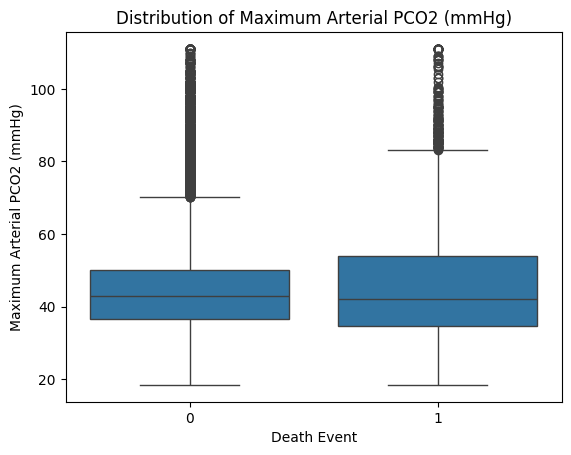

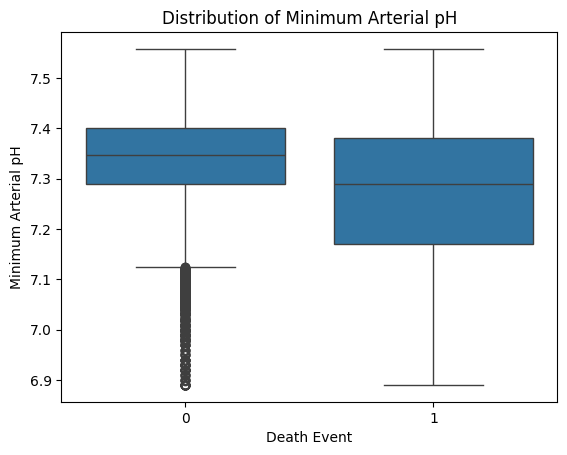

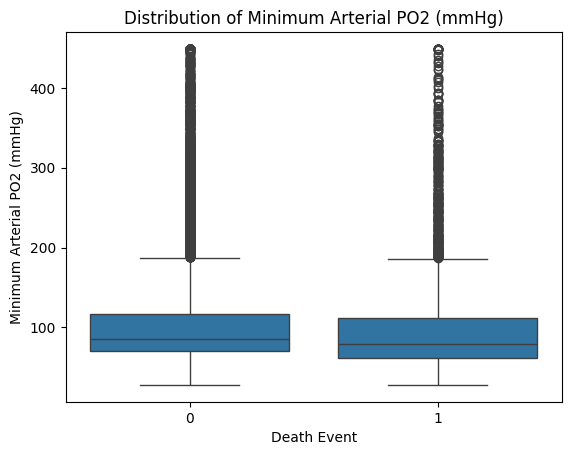

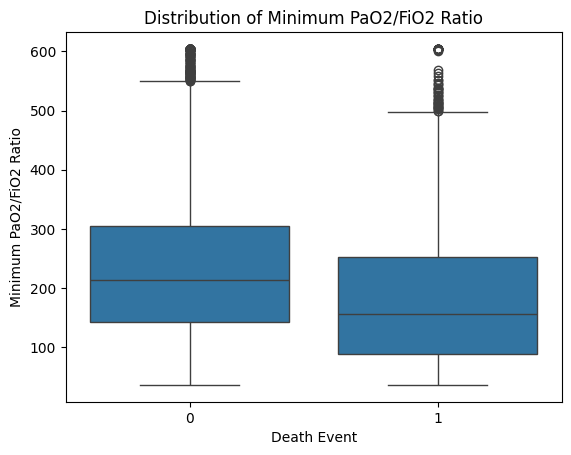

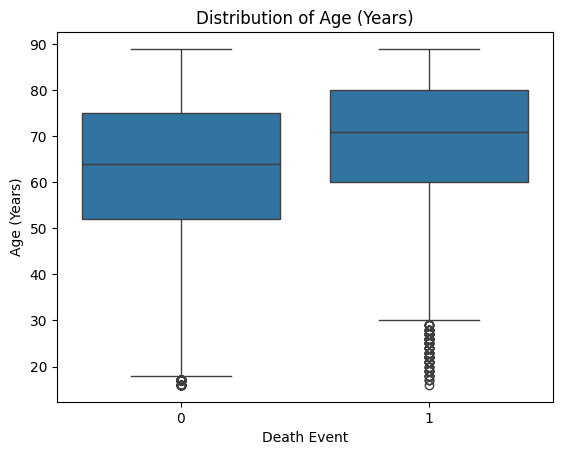

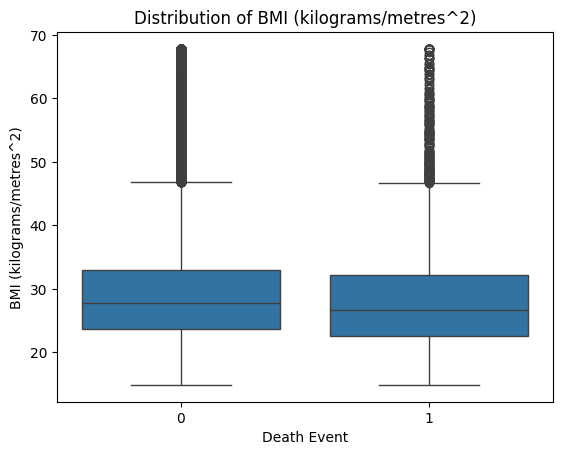

In [8]:
# ==================================================
# 4. Univariate Analysis
# ==================================================

binary_vars = [
    col for col in clinical_vars
    if col not in ["gender", "ethnicity"]
]

def var_histograms(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    fig = sns.histplot(data=train_data, x=feat, bins=20, kde=True)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.show()
  return

var_histograms(d1_vars)
var_histograms(binary_vars)

def var_boxplots(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    fig = sns.boxplot(data=train_data, x="hospital_death", y=feat)
    plt.title(f"Distribution of {label}")
    plt.xlabel("Death Event")
    plt.ylabel(label)
    plt.show()
  return

var_boxplots(d1_vars)
var_boxplots(demographic_vars)

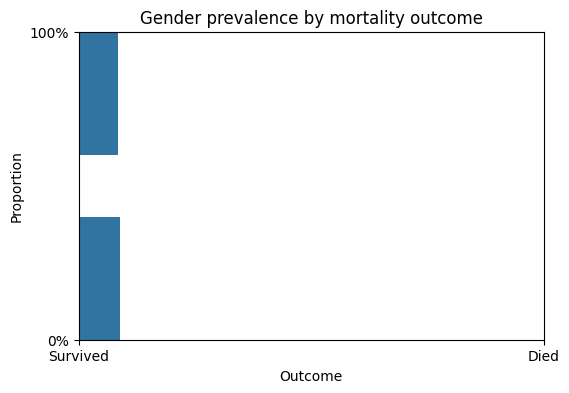

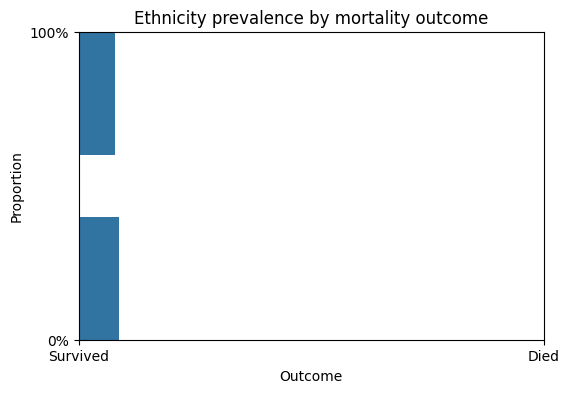

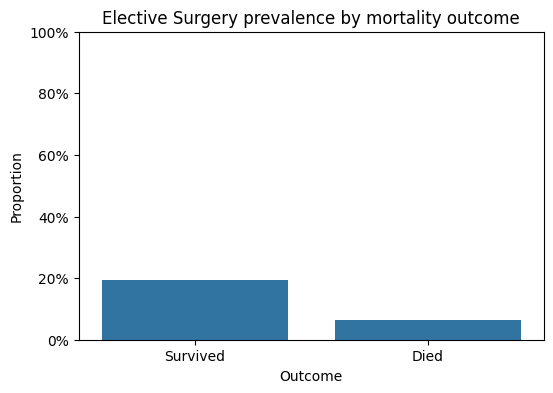

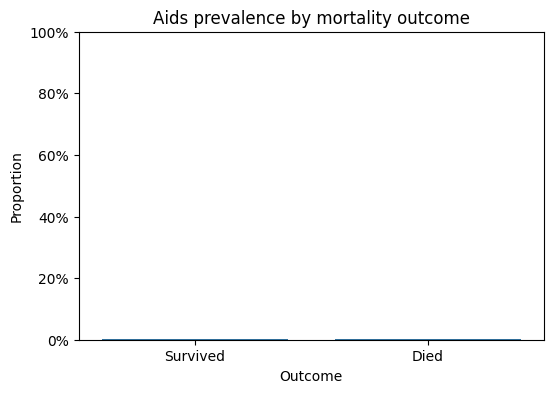

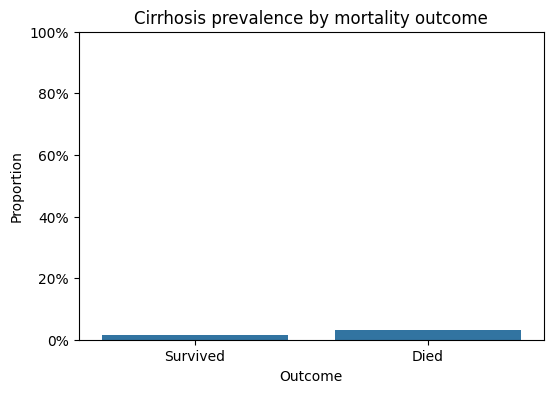

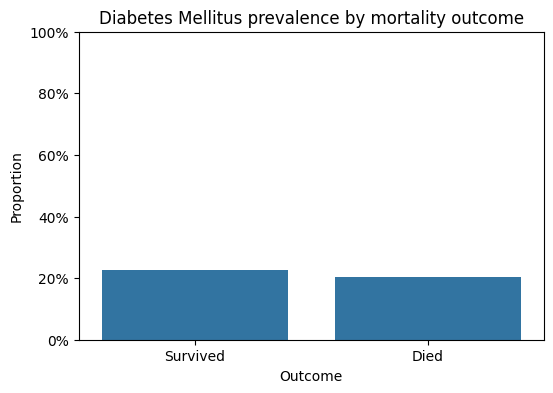

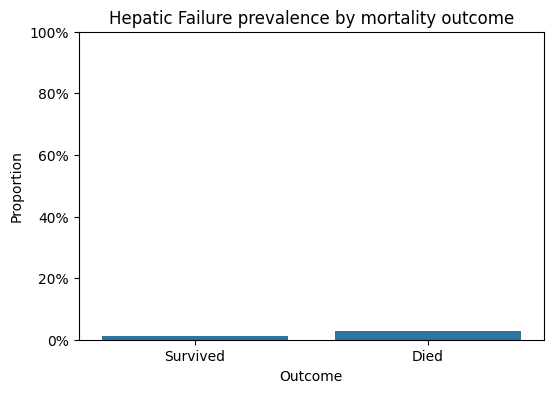

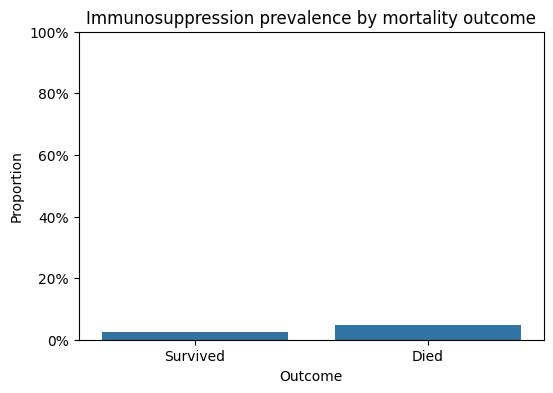

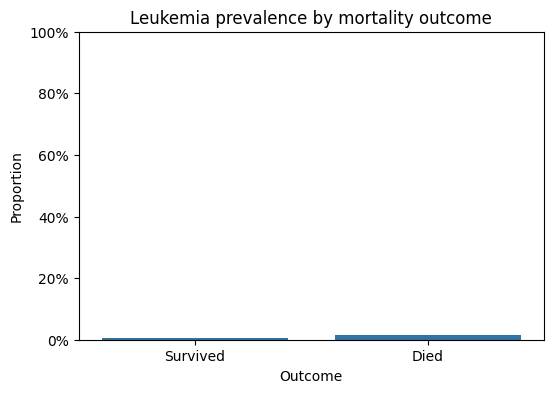

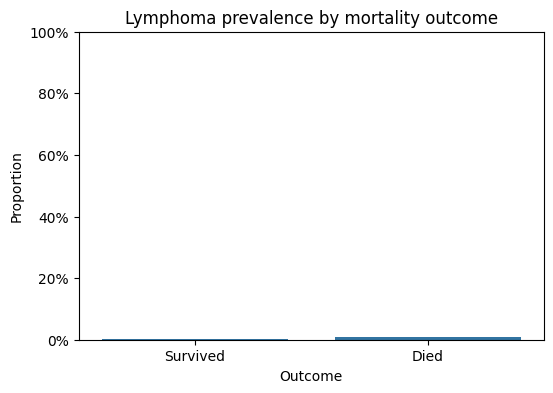

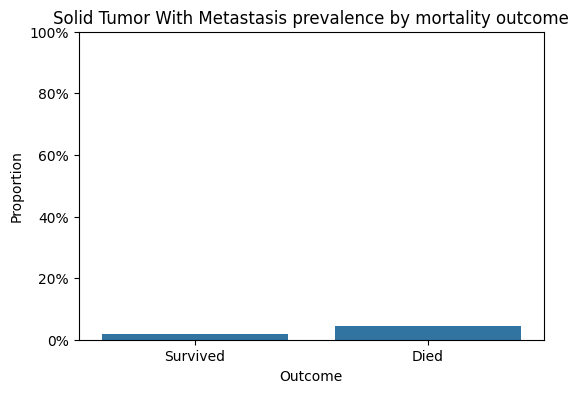

In [9]:
for feature in clinical_vars:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=train_data,
        x="hospital_death",
        y=feature,
        errorbar=None
    )

    plt.xticks(
        [0,1],
        ["Survived", "Died"]
    )

    plt.title(f"{feature.replace('_', ' ').title()} prevalence by mortality outcome")
    plt.xlabel("Outcome")
    plt.ylabel("Proportion")
    plt.ylim(0,1)
    plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

    plt.show()

**5. Statistical Analysis**


*   Checking for siginificant differences in relevant groups
*   2-Sample T-Test and Mann-Whitney-U-Test for continuous variables
*   Chi-Square-Test for categorical variables
*   Cohen's d



In [10]:
# =========================
# 5. Statistical Analysis
# =========================

death_patients = train_data[train_data["hospital_death"] == 1]
non_death_patients = train_data[train_data["hospital_death"] == 0]


def compare_groups(features, test_name="welch"):

    print(f"\n{'='*60}")
    print(f"{test_name.upper()} TEST")
    print(f"{'='*60}")

    for feature in features:
        label = variable_labels.get(feature, feature)
        group1 = death_patients[feature].dropna()
        group2 = non_death_patients[feature].dropna()

        if test_name == "welch":
            statistic, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False
            )

        elif test_name == "mannwhitney":
            statistic, p_value = stats.mannwhitneyu(
                group1,
                group2,
                alternative="two-sided"
            )

        print(
            f"{label:<20}"
            f"Statistic = {statistic:>10.2f}"
            f"   p = {p_value:.3e}"
        )
def compare_categorical(features):

    print(f"\n{'='*60}")
    print("CHI-SQUARE TEST")
    print(f"{'='*60}")

    for feature in features:
        label = variable_labels.get(feature, feature)
        table = pd.crosstab(
            train_data[feature],
            train_data["hospital_death"]
        )

        chi2, p_value, dof, expected = stats.chi2_contingency(table)

        print(
            f"{label:<25}"
            f"Chi2={chi2:>10.2f}"
            f" p={p_value:.3e}"
        )

def cohens_d(features):

    print(f"\n{'='*60}")
    print("Cohens D")
    print(f"{'='*60}")

    for feature in features:
      label = variable_labels.get(feature, feature)
      group1 = death_patients[feature].dropna()
      group2 = non_death_patients[feature].dropna()

      n1, n2 = len(group1), len(group2)
      var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

      # Pooled standard deviation
      pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

      # Cohen's d formula
      effect_size = (np.mean(group1) - np.mean(group2)) / pooled_std

      print(
            f"{label:<20}"
            f"Cohens D = {effect_size:>10.2f}"
        )

    return


compare_groups(d1_vars, test_name="welch")
compare_groups(d1_vars, test_name="mannwhitney")
compare_categorical(clinical_vars)
cohens_d(d1_vars)


WELCH TEST
Maximum Heartrate (bpm)Statistic =      39.29   p = 3.695e-306
Minimum Heartrate (bpm)Statistic =      -0.11   p = 9.145e-01
Maximum Mean Blood Pressure (mmHg)Statistic =      -3.95   p = 7.794e-05
Minimum Mean Blood Pressure (mmHg)Statistic =     -50.37   p = 0.000e+00
Maximum Respiratory Rate (breaths/min)Statistic =      25.93   p = 7.104e-142
Minimum Respiratory Rate (breaths/min)Statistic =       5.34   p = 9.590e-08
Minimum Blood Oxygen Saturation (%)Statistic =     -32.71   p = 1.541e-217
Maximum Systolic Blood Pressure (mmHg)Statistic =      -6.20   p = 6.056e-10
Minimum Systolic Blood Pressure (mmHg)Statistic =     -52.70   p = 0.000e+00
Maximum Temperature (°C)Statistic =       2.04   p = 4.180e-02
Minimum Temperature (°C)Statistic =     -31.04   p = 5.063e-197
Minimum Albumin (g/L)Statistic =     -37.01   p = 9.007e-263
Maximum Bilirubin (µmol/l)Statistic =      14.50   p = 2.376e-46
Urea Nitrogen (mmol/l)Statistic =      40.06   p = 0.000e+00
Maximum Calcium (mm

Missingness differed by mortality outcome, particularly for maximum day-one lactate: values were missing in 76.9% of survivors and 49.1% of non-survivors. Lactate availability was therefore associated with the outcome. Comparisons of observed lactate values describe a selected subset of patients and should be reported alongside the number of available observations. The reasons for missingness cannot be determined from this analysis alone.

In [11]:
summary = (
    train_data
    .groupby("hospital_death")[eda_vars]
    .agg(["count", "median", "min", "max"])
    .T
)

summary.columns = ["Survived", "Died"]
display(summary.round(2))

Survived     Died
age               count   64123.00  5803.00
                  median     64.00    71.00
                  min        16.00    16.00
                  max        89.00    89.00
d1_heartrate_max  count   66933.00  6318.00
                  median    100.00   114.00
                  min        58.00    58.00
                  max       177.00   177.00
d1_mbp_min        count   66885.00  6310.00
                  median     65.00    54.00
                  min        22.00    22.00
                  max       112.00   112.00
d1_spo2_min       count   66808.00  6293.00
                  median     93.00    90.00
                  min         0.00     0.00
                  max       100.00   100.00
d1_creatinine_max count   59597.00  5658.00
                  median      0.99     1.55
                  min         0.34     0.34
                  max        11.11    11.11
d1_lactate_max    count   15499.00  3225.00
                  median      1.70     3.60
                  min         0.40     0.40
                  max        19.80    19.80

In [12]:
quartiles = (
    train_data
    .groupby("hospital_death")[["d1_mbp_min", "d1_lactate_max"]]
    .quantile([0.25, 0.50, 0.75])
)
display(quartiles)

spo2_check = train_data.groupby("hospital_death")["d1_spo2_min"].agg(
    available_n="count",
    zero_n=lambda values: values.eq(0).sum()
)
spo2_check["zero_pct_of_available"] = (
    100 * spo2_check["zero_n"] / spo2_check["available_n"]
)
display(spo2_check.round(2))

d1_mbp_min  d1_lactate_max
hospital_death                                 
0              0.25        56.0             1.1
               0.50        65.0             1.7
               0.75        75.0             2.8
1              0.25        44.0             1.9
               0.50        54.0             3.6
               0.75        65.0             7.7

,available_n,zero_n,zero_pct_of_available
hospital_death,,,
0,66808,91,0.14
1,6293,38,0.60


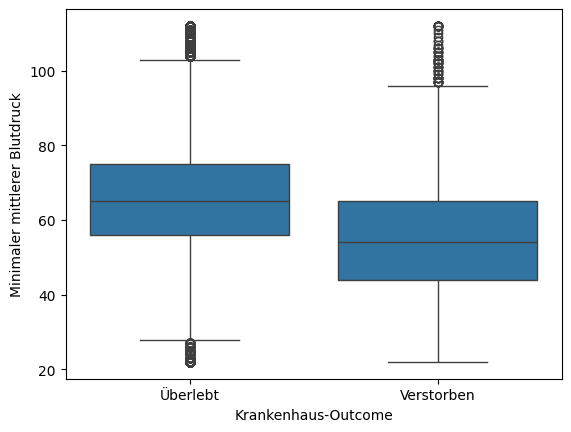

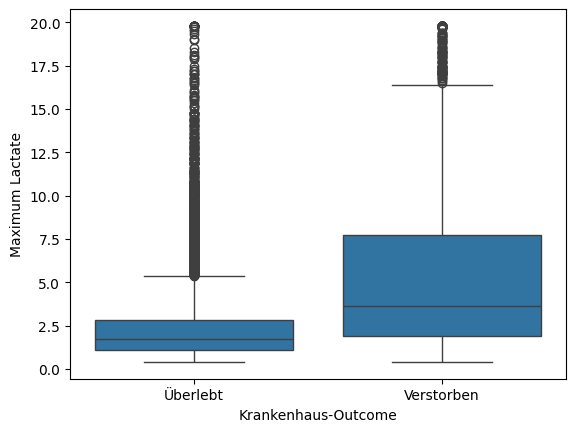

In [13]:
sns.boxplot(
    data=train_data,
    x="hospital_death",
    y="d1_mbp_min"
)

plt.xticks([0, 1], ["Überlebt", "Verstorben"])
plt.xlabel("Krankenhaus-Outcome")
plt.ylabel("Minimaler mittlerer Blutdruck")
plt.show()

sns.boxplot(
    data=train_data,
    x="hospital_death",
    y="d1_lactate_max"
)

plt.xticks([0, 1], ["Überlebt", "Verstorben"])
plt.xlabel("Krankenhaus-Outcome")
plt.ylabel("Maximum Lactate")
plt.show()

Patients who died in hospital had a lower median minimum day-one mean blood pressure and a higher median maximum day-one lactate than survivors. The distributions overlapped, so neither variable alone clearly separated the two groups. Lactate results should be interpreted cautiously because values were missing for many patients, particularly survivors.

Statistical comparisons identified differences between survivors and non-survivors across several variables. Minimum day-one mean blood pressure was lower among non-survivors (Cohen’s d = −0.71), while maximum day-one lactate was higher (d = 1.15).

Many p-values were very small, but statistical significance did not always indicate a substantial difference. For example, maximum mean blood pressure had a small effect size (d = −0.06) despite a statistically significant Welch test.

These results are exploratory and do not establish causation or predictive performance. Lactate findings apply only to patients with available measurements, and missingness differed between outcome groups. Multiple comparisons were performed without adjustment.

**6. Traing- and Test-Set**

In [14]:
total_vars = clinical_vars + d1_vars + demographic_vars

X_train = train_data[total_vars].copy()
y_train = train_data["hospital_death"].copy()

X_test = test_data[total_vars].copy()
y_test = test_data["hospital_death"].copy()

categorical_cols = ["gender", "ethnicity"]

numeric_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print(X_train[categorical_cols].dtypes)
print(X_train[numeric_cols].dtypes)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

gender       object
ethnicity    object
dtype: object
elective_surgery                 int64
aids                           float64
cirrhosis                      float64
diabetes_mellitus              float64
hepatic_failure                float64
immunosuppression              float64
leukemia                       float64
lymphoma                       float64
solid_tumor_with_metastasis    float64
d1_heartrate_max               float64
d1_heartrate_min               float64
d1_mbp_max                     float64
d1_mbp_min                     float64
d1_resprate_max                float64
d1_resprate_min                float64
d1_spo2_min                    float64
d1_sysbp_max                   float64
d1_sysbp_min                   float64
d1_temp_max                    float64
d1_temp_min                    float64
d1_albumin_min                 float64
d1_bilirubin_max               float64
d1_bun_max                     float64
d1_calcium_max                 float64
d1_calcium

## 7. Dummy Classifier Baseline

A `DummyClassifier` was evaluated with five-fold stratified group cross-validation.

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     67038
           1       0.00      0.00      0.00      6332

    accuracy                           0.91     73370
   macro avg       0.46      0.50      0.48     73370
weighted avg       0.83      0.91      0.87     73370



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


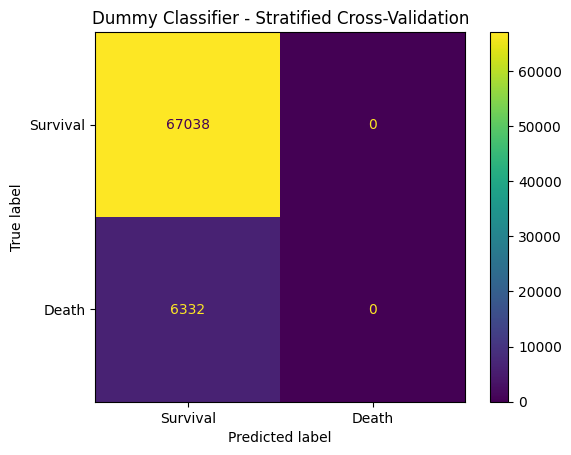

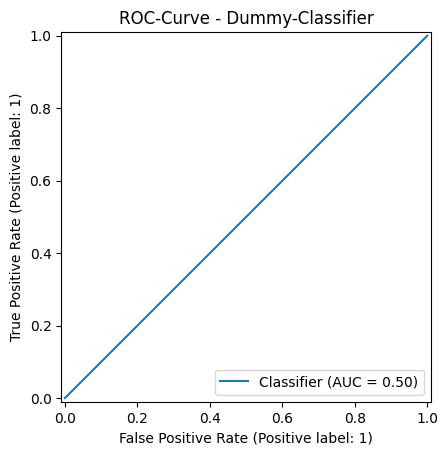

ROC-AUC: 0.500


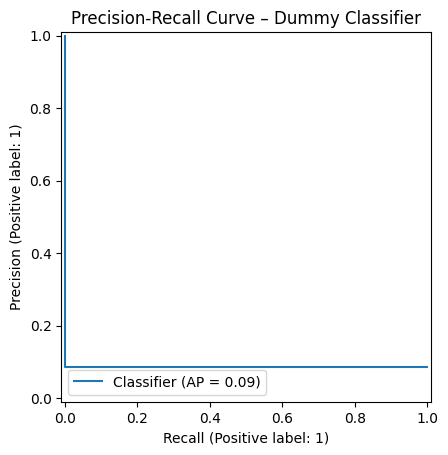

Average Precision: 0.086


In [15]:
# Define the cross-validation splitter
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dummy_model = DummyClassifier(strategy="prior")
dummy_pred = cross_val_predict(dummy_model, X_train, y_train, cv=cv, method="predict")
dummy_prob = cross_val_predict(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

#Classification Report
print(classification_report(y_train, dummy_pred))

#Confusion Matrix
cm = confusion_matrix(y_train, dummy_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("Dummy Classifier - Stratified Cross-Validation")
plt.show()

#ROC Curve using probabilities
RocCurveDisplay.from_predictions(y_train, dummy_prob)
plt.title("ROC-Curve - Dummy-Classifier")
plt.show()

dummy_roc_auc = roc_auc_score(y_train, dummy_prob)
print(f"ROC-AUC: {dummy_roc_auc:.3f}")

PrecisionRecallDisplay.from_predictions(
    y_train,
    dummy_prob
)

plt.title("Precision-Recall Curve – Dummy Classifier")
plt.show()

dummy_average_precision = average_precision_score(
    y_train,
    dummy_prob
)

print(
    "Average Precision:",
    f"{dummy_average_precision:.3f}"
)

**8. Logistic Regression**

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     67038
           1       0.25      0.73      0.37      6332

    accuracy                           0.78     73370
   macro avg       0.61      0.76      0.62     73370
weighted avg       0.91      0.78      0.83     73370



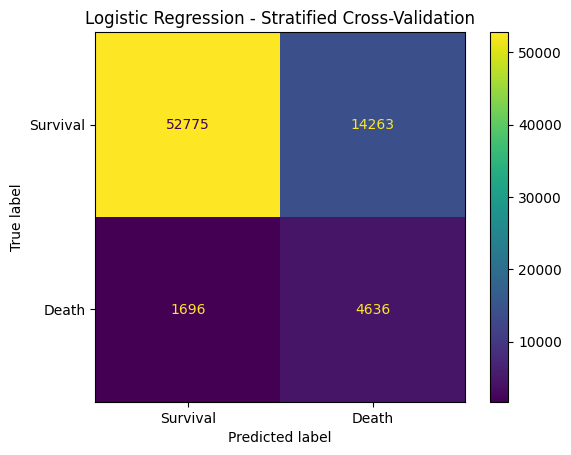

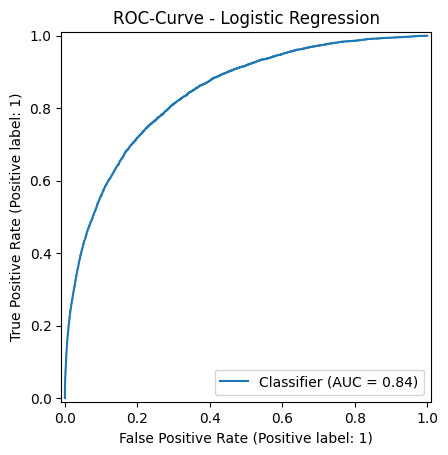

ROC-AUC: 0.841


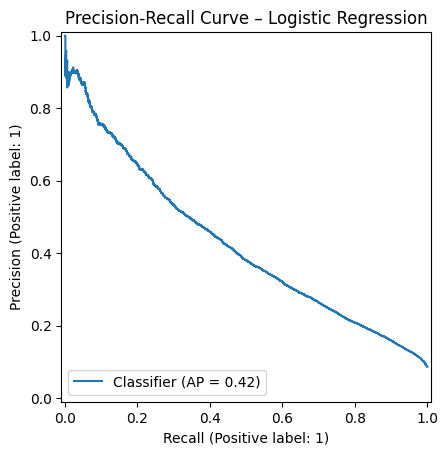

Average Precision: 0.424


In [17]:
# Logistic Regression

balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

# Predictions

lgr_prob = cross_val_predict(
    balanced_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

lgr_pred = (lgr_prob >= 0.5).astype(int)

# Classification Report

print(classification_report(y_train, lgr_pred))

# Confusion Matrix

cm = confusion_matrix(y_train, lgr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("Logistic Regression - Stratified Cross-Validation")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y_train, lgr_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - Logistic Regression")
plt.show()

lgr_roc_auc = roc_auc_score(y_train, lgr_prob)
print(f"ROC-AUC: {lgr_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y_train,
    lgr_prob
)

plt.title("Precision-Recall Curve – Logistic Regression")
plt.show()

lgr_average_precision = average_precision_score(
    y_train,
    lgr_prob
)

print(
    "Average Precision:",
    f"{lgr_average_precision:.3f}"
)

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     16760
           1       0.25      0.74      0.37      1583

    accuracy                           0.79     18343
   macro avg       0.61      0.76      0.62     18343
weighted avg       0.91      0.79      0.83     18343

Test ROC-AUC: 0.8504884460037058


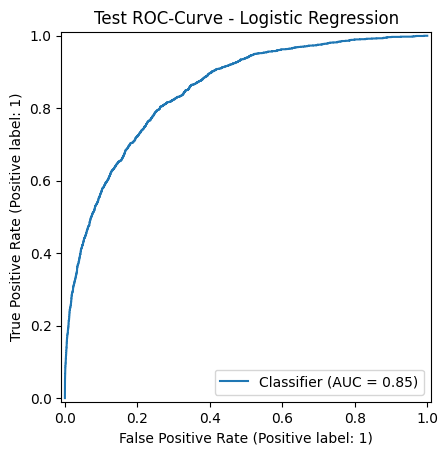

Test ROC-AUC: 0.850


In [18]:
# Auf allen Trainingsdaten lernen
balanced_pipeline.fit(X_train, y_train)

# Vorhersagen für die Testdaten
test_prob = balanced_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

# Mit den tatsächlichen Test-Outcomes vergleichen
print(classification_report(y_test, test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, test_prob))

# ROC Curve and ROC-AUC
RocCurveDisplay.from_predictions(y_test, test_prob) # Use probabilities for ROC curve
plt.title("Test ROC-Curve - Logistic Regression")
plt.show()

test_roc_auc = roc_auc_score(y_test, test_prob)
print(f"Test ROC-AUC: {test_roc_auc:.3f}")

The logistic regression pipeline was fitted on the full training set and evaluated on the held-out test set. It achieved a test ROC-AUC of approximately 0.85, similar to the cross-validation result of 0.841.

At a classification threshold of 0.5, the model identified approximately 74% of patients who died in hospital (recall = 0.74). However, only 25% of patients predicted to die actually died (precision = 0.25), indicating many false positives.

Unlike the dummy classifier, which predicted survival for every patient, logistic regression identified a substantial proportion of deaths. These results provide a useful learning baseline, but do not establish clinical suitability. The full dataset had been explored before the split, and performance on unseen hospitals remains untested.

**9. Random Forrest**

              precision    recall  f1-score   support

           0       0.96      0.89      0.92     67038
           1       0.34      0.62      0.44      6332

    accuracy                           0.87     73370
   macro avg       0.65      0.75      0.68     73370
weighted avg       0.91      0.87      0.88     73370



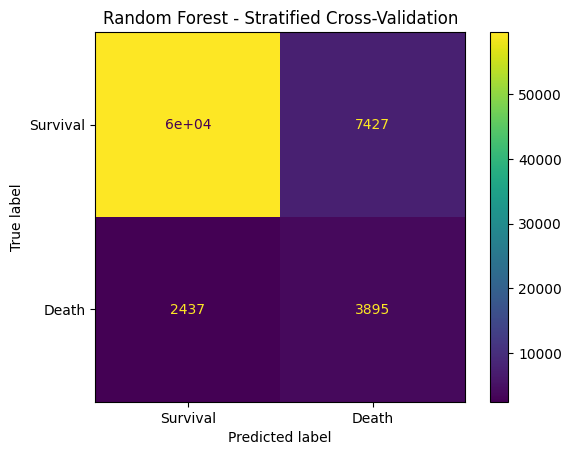

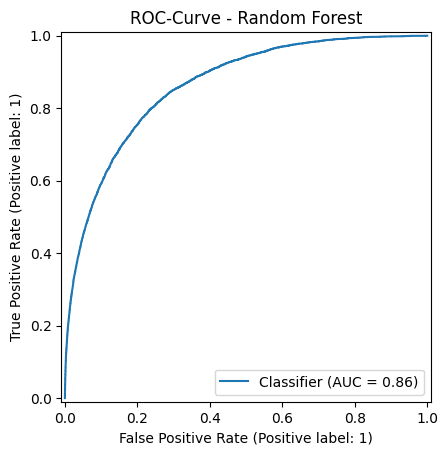

ROC-AUC: 0.863


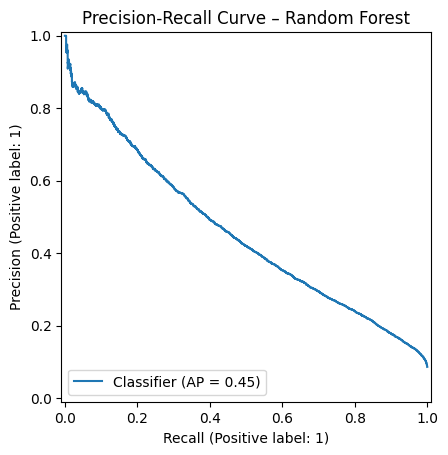

Average Precision: 0.455


In [19]:
# Random Forrest

rf_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

#cv_params = {"max_depth": [2,3,4,None],
#            "min_samples_leaf": [1,2,3],
#           "min_samples_split": [2,3,4],
#          "max_features": [2,3,4],
#         "n_estimators": [75,100,125,150]}

#scoring = {"accuracy", "precision", "recall", "f1"}

#rf_grid_search = GridSearchCV(
#    rf_pipeline,
#    cv_params,
#    cv=cv,
#    scoring=scoring,
#    refit="f1")

#rf_grid_search.fit(X_train, y_train)

#cv_results = pd.DataFrame(rf_grid_search.cv_results_)

# Predictions
rf_prob = cross_val_predict(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

rf_pred = (rf_prob >= 0.5).astype(int)

# Classification Report

print(classification_report(y_train, rf_pred))

# Confusion Matrix

cm = confusion_matrix(y_train, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot(values_format="d")
plt.title("Random Forest - Stratified Cross-Validation")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y_train, rf_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - Random Forest")
plt.show()

rf_roc_auc = roc_auc_score(y_train, rf_prob)
print(f"ROC-AUC: {rf_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y_train,
    rf_prob
)

plt.title("Precision-Recall Curve – Random Forest")
plt.show()

rf_average_precision = average_precision_score(
    y_train,
    rf_prob
)

print(
    "Average Precision:",
    f"{rf_average_precision:.3f}"
)

In [25]:
rf_pipeline.fit(X_train, y_train)

rf_test_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_test_pred = (rf_test_prob >= 0.5).astype(int)

print(classification_report(y_test, rf_test_pred))

print("Test ROC-AUC:",
      round(roc_auc_score(y_test, rf_test_prob), 3))

print("Test Average Precision:",
      round(average_precision_score(y_test, rf_test_prob), 3))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92     16760
           1       0.34      0.64      0.44      1583

    accuracy                           0.86     18343
   macro avg       0.65      0.76      0.68     18343
weighted avg       0.91      0.86      0.88     18343

Test ROC-AUC: 0.867
Test Average Precision: 0.471


**9. XGBoost**

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     67038
           1       0.72      0.24      0.36      6332

    accuracy                           0.93     73370
   macro avg       0.82      0.62      0.66     73370
weighted avg       0.91      0.93      0.91     73370



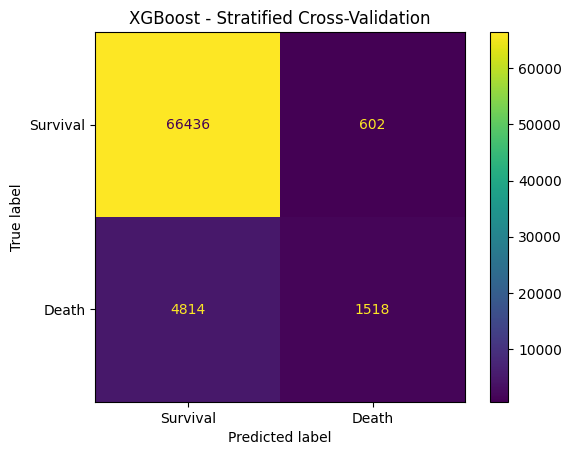

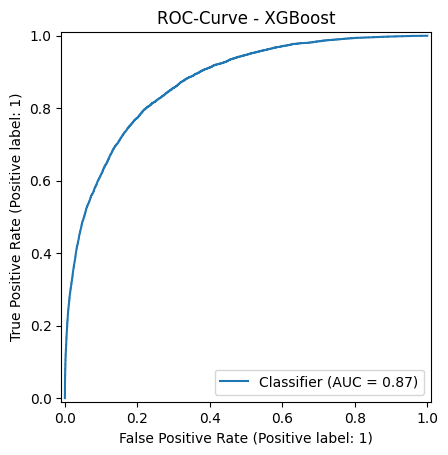

ROC-AUC: 0.872


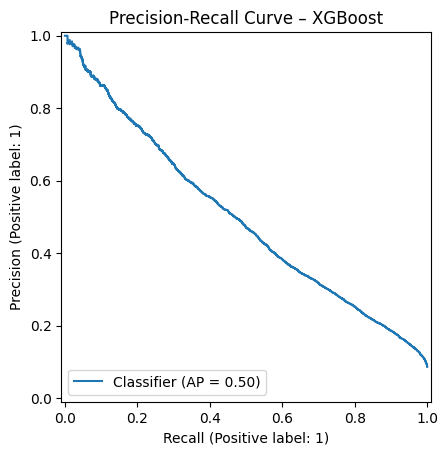

Average Precision: 0.497


In [21]:
# XGBoost

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=2
    ))
])

#cv_params = {"max_depth": [2,3,4,None],
#             "min_samples_leaf": [1,2,3],
#             "min_sample_split": [2,3,4],
#             "max_features": [2,3,4],
#             "n_estimators": [75,100,125,150]}

#scoring = {"accuracy", "precision", "recall", "f1"}

#xgb_grid_search = GridSearchCV(
#    xgb_pipeline,
#    cv_params,
#    cv=cv,
#    scoring=scoring,
#    refit="f1")

#xgb_grid_search.fit(X_train, y_train)

#cv_results = pd.DataFrame(xgb_grid_search.cv_results_)

# Predictions
xgb_prob = cross_val_predict(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

xgb_pred = (xgb_prob >= 0.5).astype(int)

# Classification Report

print(classification_report(y_train, xgb_pred))

# Confusion Matrix

cm = confusion_matrix(y_train, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("XGBoost - Stratified Cross-Validation")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y_train, xgb_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - XGBoost")
plt.show()

xgb_roc_auc = roc_auc_score(y_train, xgb_prob)
print(f"ROC-AUC: {xgb_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y_train,
    xgb_prob
)

plt.title("Precision-Recall Curve – XGBoost")
plt.show()

xgb_average_precision = average_precision_score(
    y_train,
    xgb_prob
)

print(
    "Average Precision:",
    f"{xgb_average_precision:.3f}"
)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     67038
           1       0.55      0.40      0.47      6332

    accuracy                           0.92     73370
   macro avg       0.75      0.69      0.71     73370
weighted avg       0.91      0.92      0.91     73370



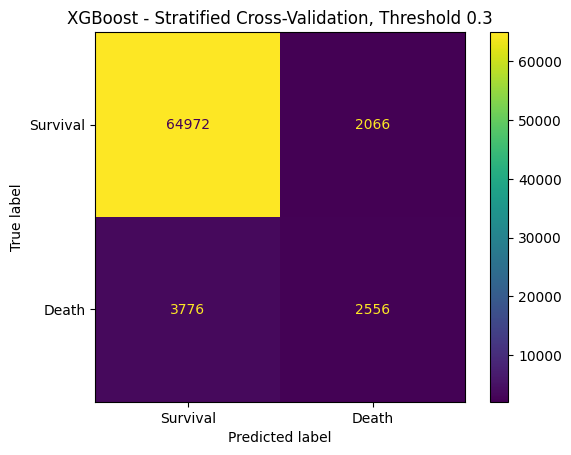

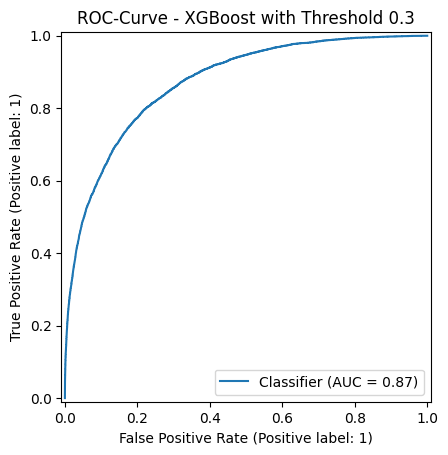

ROC-AUC: 0.872


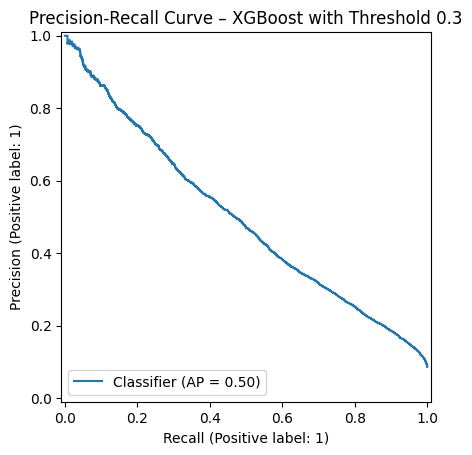

Average Precision: 0.497


In [23]:
xgb_pred_03 = (xgb_prob >= 0.3).astype(int)

# Classification Report

print(classification_report(y_train, xgb_pred_03))

# Confusion Matrix

cm = confusion_matrix(y_train, xgb_pred_03)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("XGBoost - Stratified Cross-Validation, Threshold 0.3")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y_train, xgb_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - XGBoost")
plt.show()

xgb_roc_auc = roc_auc_score(y_train, xgb_prob)
print(f"ROC-AUC: {xgb_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y_train,
    xgb_prob
)

plt.title("Precision-Recall Curve – XGBoost")
plt.show()

xgb_average_precision = average_precision_score(
    y_train,
    xgb_prob
)

print(
    "Average Precision:",
    f"{xgb_average_precision:.3f}"
)

Lowering the XGBoost classification threshold from 0.5 to 0.3 increased recall for in-hospital deaths from 0.24 to 0.40, while precision decreased from 0.72 to 0.55. This identified 1,038 additional deaths but produced 1,464 additional false positives. ROC-AUC and average precision remained unchanged because the underlying predicted scores were unchanged. The threshold of 0.3 was explored as an example and was not established as optimal.

In [24]:
# Auf allen Trainingsdaten lernen
xgb_pipeline.fit(X_train, y_train)

# Vorhersagen für die Testdaten
xgb_test_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.3]:
    xgb_test_pred = (xgb_test_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, xgb_test_pred))

print("Test ROC-AUC:",
      round(roc_auc_score(y_test, xgb_test_prob), 3))

print("Test Average Precision:",
      round(average_precision_score(y_test, xgb_test_prob), 3))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     16760
           1       0.74      0.25      0.37      1583

    accuracy                           0.93     18343
   macro avg       0.84      0.62      0.67     18343
weighted avg       0.92      0.93      0.91     18343


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     16760
           1       0.57      0.42      0.48      1583

    accuracy                           0.92     18343
   macro avg       0.76      0.70      0.72     18343
weighted avg       0.91      0.92      0.92     18343

Test ROC-AUC: 0.879
Test Average Precision: 0.527
